<a href="https://colab.research.google.com/github/arnavon2005/Army_Provost_ML_Project/blob/main/06_Decision_Support_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision-Support System

This notebook develops the decision-support layer of the Army Provost ML project. It builds upon the completed exploratory analysis and machine-learning model developed in the previous notebooks.

The objective is to transform incident-level predictions and historical crime patterns into interpretable information that can assist control-room personnel with incident assessment, prioritization, and response planning.

The system is a decision-support prototype. It does not autonomously make operational decisions or claim to represent official Indian Army doctrine.

In [1]:
# ============================================================
# DECISION-SUPPORT SYSTEM
# PROJECT ENVIRONMENT SETUP
# ============================================================

from google.colab import drive
import os

print("=" * 70)
print("ARMY PROVOST DECISION-SUPPORT SYSTEM")
print("PROJECT ENVIRONMENT SETUP")
print("=" * 70)

# ------------------------------------------------------------
# Mount Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive")

# ------------------------------------------------------------
# Existing project root
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"

DATASETS_PATH = os.path.join(
    PROJECT_ROOT,
    "Datasets"
)

CLEANED_DATA_PATH = os.path.join(
    DATASETS_PATH,
    "Cleaned"
)

MODELS_PATH = os.path.join(
    PROJECT_ROOT,
    "Models"
)

FIGURES_PATH = os.path.join(
    PROJECT_ROOT,
    "Figures"
)

OUTPUTS_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs"
)

REPORTS_PATH = os.path.join(
    PROJECT_ROOT,
    "Reports"
)

LOGS_PATH = os.path.join(
    PROJECT_ROOT,
    "Logs"
)

# ------------------------------------------------------------
# Important saved ML artifacts
# ------------------------------------------------------------

RF_MODEL_PATH = os.path.join(
    MODELS_PATH,
    "final_random_forest.pkl"
)

PREPROCESSING_PIPELINE_PATH = os.path.join(
    MODELS_PATH,
    "preprocessing_pipeline.pkl"
)

# ------------------------------------------------------------
# Verify project structure
# ------------------------------------------------------------

required_directories = [
    PROJECT_ROOT,
    DATASETS_PATH,
    CLEANED_DATA_PATH,
    MODELS_PATH,
    FIGURES_PATH,
    OUTPUTS_PATH,
    REPORTS_PATH,
    LOGS_PATH
]

print("\nChecking project directories...\n")

all_directories_available = True

for path in required_directories:
    exists = os.path.isdir(path)

    print(
        f"{'✓' if exists else '✗'} "
        f"{path}"
    )

    if not exists:
        all_directories_available = False

# ------------------------------------------------------------
# Verify important ML artifacts
# ------------------------------------------------------------

print("\nChecking important ML artifacts...\n")

required_files = [
    RF_MODEL_PATH,
    PREPROCESSING_PIPELINE_PATH,
    os.path.join(
        OUTPUTS_PATH,
        "Final_Random_Forest_Diagnostic_Summary.csv"
    ),
    os.path.join(
        OUTPUTS_PATH,
        "Final_Model_Performance_Comparison.csv"
    )
]

all_files_available = True

for path in required_files:
    exists = os.path.isfile(path)

    print(
        f"{'✓' if exists else '✗'} "
        f"{os.path.basename(path)}"
    )

    if not exists:
        all_files_available = False

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)

if all_directories_available and all_files_available:
    print("PROJECT ENVIRONMENT VERIFIED SUCCESSFULLY")
    print("Ready to begin the Decision-Support System phase.")
else:
    print("PROJECT ENVIRONMENT VERIFICATION INCOMPLETE")
    print("Review the missing paths/files above before proceeding.")

print("=" * 70)

print("\nProject Root:")
print(PROJECT_ROOT)

ARMY PROVOST DECISION-SUPPORT SYSTEM
PROJECT ENVIRONMENT SETUP
Mounted at /content/drive

Checking project directories...

✓ /content/drive/MyDrive/Army_Provost_ML_Project
✓ /content/drive/MyDrive/Army_Provost_ML_Project/Datasets
✓ /content/drive/MyDrive/Army_Provost_ML_Project/Datasets/Cleaned
✓ /content/drive/MyDrive/Army_Provost_ML_Project/Models
✓ /content/drive/MyDrive/Army_Provost_ML_Project/Figures
✓ /content/drive/MyDrive/Army_Provost_ML_Project/Outputs
✓ /content/drive/MyDrive/Army_Provost_ML_Project/Reports
✓ /content/drive/MyDrive/Army_Provost_ML_Project/Logs

Checking important ML artifacts...

✓ final_random_forest.pkl
✓ preprocessing_pipeline.pkl
✓ Final_Random_Forest_Diagnostic_Summary.csv
✓ Final_Model_Performance_Comparison.csv

PROJECT ENVIRONMENT VERIFIED SUCCESSFULLY
Ready to begin the Decision-Support System phase.

Project Root:
/content/drive/MyDrive/Army_Provost_ML_Project


In [2]:
# ============================================================
# PRIMARY INCIDENT CATEGORY INVENTORY
# DECISION-SUPPORT SYSTEM
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("PRIMARY INCIDENT CATEGORY INVENTORY")
print("=" * 70)

# ------------------------------------------------------------
# Existing project paths
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"

CLEANED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "Datasets",
    "Cleaned"
)

CLEANED_FILE = os.path.join(
    CLEANED_DATA_PATH,
    "chicago_crimes_cleaned.csv"
)

# ------------------------------------------------------------
# Verify dataset exists
# ------------------------------------------------------------

if not os.path.isfile(CLEANED_FILE):
    raise FileNotFoundError(
        f"Cleaned dataset not found:\n{CLEANED_FILE}"
    )

print("\nDataset found:")
print(CLEANED_FILE)

# ------------------------------------------------------------
# Read ONLY Primary Type
# ------------------------------------------------------------

print("\nReading only the 'Primary Type' column...")
print("The full dataset will NOT be loaded into memory.")

primary_type_series = pd.read_csv(
    CLEANED_FILE,
    usecols=["Primary Type"]
)["Primary Type"]

# ------------------------------------------------------------
# Generate category inventory
# ------------------------------------------------------------

primary_type_counts = (
    primary_type_series
    .value_counts(dropna=False)
    .reset_index()
)

primary_type_counts.columns = [
    "Primary Type",
    "Incident Count"
]

primary_type_counts["Percentage"] = (
    primary_type_counts["Incident Count"]
    / primary_type_counts["Incident Count"].sum()
    * 100
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CATEGORY INVENTORY")
print("=" * 70)

print(
    f"\nTotal records inspected: "
    f"{len(primary_type_series):,}"
)

print(
    f"Unique Primary Type categories: "
    f"{primary_type_series.nunique(dropna=True)}"
)

print("\nComplete Primary Type Distribution:\n")

display(
    primary_type_counts.round({
        "Percentage": 2
    })
)

# ------------------------------------------------------------
# Save inventory permanently
# ------------------------------------------------------------

OUTPUTS_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs"
)

taxonomy_inventory_path = os.path.join(
    OUTPUTS_PATH,
    "Primary_Type_Category_Inventory.csv"
)

primary_type_counts.to_csv(
    taxonomy_inventory_path,
    index=False
)

print("=" * 70)
print("CATEGORY INVENTORY SAVED")
print("=" * 70)

print("\nSaved to:")
print(taxonomy_inventory_path)

PRIMARY INCIDENT CATEGORY INVENTORY

Dataset found:
/content/drive/MyDrive/Army_Provost_ML_Project/Datasets/Cleaned/chicago_crimes_cleaned.csv

Reading only the 'Primary Type' column...
The full dataset will NOT be loaded into memory.

CATEGORY INVENTORY

Total records inspected: 8,602,734
Unique Primary Type categories: 34

Complete Primary Type Distribution:



,Primary Type,Incident Count,Percentage
0,THEFT,1827377,21.24
1,BATTERY,1567212,18.22
2,CRIMINAL DAMAGE,977357,11.36
3,NARCOTICS,768704,8.94
4,ASSAULT,580094,6.74
5,OTHER OFFENSE,537540,6.25
6,BURGLARY,455436,5.29
7,MOTOR VEHICLE THEFT,444725,5.17
8,DECEPTIVE PRACTICE,400071,4.65
9,ROBBERY,318103,3.70


CATEGORY INVENTORY SAVED

Saved to:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Primary_Type_Category_Inventory.csv


In [3]:
# ============================================================
# CORRECT AND VALIDATE ARMY PROVOST INCIDENT TAXONOMY
# ============================================================

import pandas as pd
from pathlib import Path

print("=" * 70)
print("CORRECTING ARMY PROVOST INCIDENT TAXONOMY")
print("=" * 70)

# ------------------------------------------------------------
# Existing project path
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Army_Provost_ML_Project"
)

OUTPUTS_PATH = PROJECT_ROOT / "Outputs"

taxonomy_path = (
    OUTPUTS_PATH / "Army_Provost_Incident_Taxonomy.csv"
)

# ------------------------------------------------------------
# Corrected taxonomy
# ------------------------------------------------------------

taxonomy_data = [

    [
        "THEFT",
        "Property & Asset Security",
        "Theft / Property Loss",
        "Moderate",
        "Involves unauthorized taking or loss of property or assets."
    ],

    [
        "BATTERY",
        "Personnel & Physical Safety",
        "Physical Assault",
        "High",
        "Involves physical harm or attempted physical harm to a person."
    ],

    [
        "CRIMINAL DAMAGE",
        "Property & Asset Security",
        "Property Damage",
        "Moderate",
        "Involves intentional damage to property or assets."
    ],

    [
        "NARCOTICS",
        "Controlled Substances",
        "Narcotics Activity",
        "High",
        "Involves controlled-substance related activity."
    ],

    [
        "ASSAULT",
        "Personnel & Physical Safety",
        "Assault / Threat of Injury",
        "High",
        "Involves an assault or threat of physical harm."
    ],

    [
        "OTHER OFFENSE",
        "Fraud, Deception & Administrative",
        "Other / Unclassified Offence",
        "Low",
        "Represents offences not captured by the major defined categories."
    ],

    [
        "BURGLARY",
        "Property & Asset Security",
        "Unauthorized Entry / Burglary",
        "Moderate",
        "Involves unlawful entry associated with property-related crime."
    ],

    [
        "MOTOR VEHICLE THEFT",
        "Vehicle & Mobility Security",
        "Vehicle Theft",
        "High",
        "Involves unauthorized taking of a motor vehicle."
    ],

    [
        "DECEPTIVE PRACTICE",
        "Fraud, Deception & Administrative",
        "Fraud / Deception",
        "Moderate",
        "Involves deceptive or fraudulent activity."
    ],

    [
        "ROBBERY",
        "Property & Asset Security",
        "Violent Property Crime",
        "High",
        "Involves property-taking accompanied by force or threat."
    ],

    [
        "CRIMINAL TRESPASS",
        "Property & Asset Security",
        "Unauthorized Access",
        "Moderate",
        "Involves unauthorized entry or presence on property."
    ],

    [
        "WEAPONS VIOLATION",
        "Weapons & Armed Security",
        "Weapons Violation",
        "High",
        "Involves unlawful possession, use, or handling of weapons."
    ],

    [
        "PROSTITUTION",
        "Sexual & Exploitation-Related",
        "Commercial Sexual Activity",
        "Moderate",
        "Represents a category involving commercial sexual activity."
    ],

    [
        "OFFENSE INVOLVING CHILDREN",
        "Child & Vulnerable-Person Safety",
        "Child-Related Offence",
        "Critical",
        "Involves an offence affecting or involving children."
    ],

    [
        "PUBLIC PEACE VIOLATION",
        "Public Order & Discipline",
        "Public Order Violation",
        "Moderate",
        "Involves disruption or violation of public peace and order."
    ],

    [
        "SEX OFFENSE",
        "Sexual & Exploitation-Related",
        "Sexual Offence",
        "High",
        "Involves a sexual offence requiring sensitive handling."
    ],

    [
        "CRIM SEXUAL ASSAULT",
        "Sexual & Exploitation-Related",
        "Sexual Assault",
        "Critical",
        "Involves sexual assault and presents a serious personnel-safety concern."
    ],

    [
        "INTERFERENCE WITH PUBLIC OFFICER",
        "Public Order & Discipline",
        "Authority / Officer Interference",
        "Moderate",
        "Involves interference with an officer or authorized public function."
    ],

    [
        "LIQUOR LAW VIOLATION",
        "Public Order & Discipline",
        "Alcohol-Related Violation",
        "Low",
        "Involves violation of applicable liquor-related regulations."
    ],

    [
        "ARSON",
        "Fire, Destructive & Major Threats",
        "Arson / Fire Threat",
        "High",
        "Involves deliberate fire-setting and potential major property or personnel risk."
    ],

    [
        "GAMBLING",
        "Public Order & Discipline",
        "Gambling Activity",
        "Low",
        "Represents gambling-related activity or violation."
    ],

    [
        "HOMICIDE",
        "Personnel & Physical Safety",
        "Fatal Violence",
        "Critical",
        "Represents fatal violence and an extreme personnel-safety concern."
    ],

    [
        "CRIMINAL SEXUAL ASSAULT",
        "Sexual & Exploitation-Related",
        "Sexual Assault",
        "Critical",
        "Involves serious sexual assault and presents a major personnel-safety concern."
    ],

    [
        "KIDNAPPING",
        "Personnel & Physical Safety",
        "Abduction / Kidnapping",
        "Critical",
        "Involves unlawful abduction or confinement of a person."
    ],

    [
        "STALKING",
        "Personnel & Physical Safety",
        "Persistent Threat / Stalking",
        "High",
        "May indicate persistent targeting or an ongoing threat to an individual."
    ],

    [
        "INTIMIDATION",
        "Personnel & Physical Safety",
        "Threat / Intimidation",
        "High",
        "Involves threats, intimidation, or coercive conduct toward a person."
    ],

    [
        "CONCEALED CARRY LICENSE VIOLATION",
        "Weapons & Armed Security",
        "Unauthorized Weapons Carry",
        "High",
        "Involves violation associated with concealed carrying of a weapon."
    ],

    [
        "OBSCENITY",
        "Public Order & Discipline",
        "Public Conduct Violation",
        "Low",
        "Represents conduct classified as an obscenity-related violation."
    ],

    [
        "PUBLIC INDECENCY",
        "Public Order & Discipline",
        "Public Conduct Violation",
        "Low",
        "Involves conduct considered inappropriate or unlawful in a public setting."
    ],

    [
        "OTHER NARCOTIC VIOLATION",
        "Controlled Substances",
        "Other Drug-Related Violation",
        "High",
        "Represents a narcotics-related violation outside the primary narcotics category."
    ],

    [
        "HUMAN TRAFFICKING",
        "Sexual & Exploitation-Related",
        "Human Trafficking",
        "Critical",
        "Represents severe exploitation involving trafficking of persons."
    ],

    [
        "NON-CRIMINAL",
        "Fraud, Deception & Administrative",
        "Non-Criminal / Administrative",
        "Low",
        "Represents records classified as non-criminal rather than a conventional offence."
    ],

    [
        "RITUALISM",
        "Public Order & Discipline",
        "Unclassified Conduct",
        "Low",
        "Represents a rare category requiring broad operational classification."
    ],

    [
        "DOMESTIC VIOLENCE",
        "Personnel & Physical Safety",
        "Domestic / Interpersonal Violence",
        "High",
        "Involves interpersonal violence and potential personnel-safety concerns."
    ]
]

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

taxonomy_df = pd.DataFrame(
    taxonomy_data,
    columns=[
        "Primary Type",
        "Provost Incident Category",
        "Incident Subcategory",
        "Priority Relevance",
        "Mapping Rationale"
    ]
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

expected_categories = 34

print("\nValidating corrected taxonomy...")
print("-" * 70)

print(f"Total taxonomy rows : {len(taxonomy_df)}")
print(f"Expected categories : {expected_categories}")
print(
    f"Unique Primary Types: "
    f"{taxonomy_df['Primary Type'].nunique()}"
)

duplicate_types = taxonomy_df[
    taxonomy_df["Primary Type"].duplicated(keep=False)
]["Primary Type"].unique()

missing_values = taxonomy_df.isnull().sum()

valid_relevance = {
    "Critical",
    "High",
    "Moderate",
    "Low"
}

invalid_relevance = set(
    taxonomy_df["Priority Relevance"].dropna()
) - valid_relevance

# ------------------------------------------------------------
# Validation results
# ------------------------------------------------------------

print("\nValidation Results")
print("-" * 70)

if len(taxonomy_df) == expected_categories:
    print("✓ Row count validation passed")
else:
    print("✗ Row count validation FAILED")

if taxonomy_df["Primary Type"].nunique() == expected_categories:
    print("✓ Unique category validation passed")
else:
    print("✗ Unique category validation FAILED")

if len(duplicate_types) == 0:
    print("✓ Duplicate category validation passed")
else:
    print("✗ Duplicate categories found:")
    print(duplicate_types)

if missing_values.sum() == 0:
    print("✓ Missing-value validation passed")
else:
    print("✗ Missing values found:")
    print(missing_values[missing_values > 0])

if len(invalid_relevance) == 0:
    print("✓ Priority relevance validation passed")
else:
    print("✗ Invalid relevance levels:")
    print(invalid_relevance)

# ------------------------------------------------------------
# Save corrected taxonomy
# ------------------------------------------------------------

taxonomy_df.to_csv(
    taxonomy_path,
    index=False
)

print("\n" + "=" * 70)
print("CORRECTED TAXONOMY SAVED")
print("=" * 70)

print(f"\nSaved to:")
print(taxonomy_path)

print("\nTaxonomy Preview:")
display(taxonomy_df)

print("\n" + "=" * 70)
print("TAXONOMY VALIDATION COMPLETED")
print("=" * 70)

CORRECTING ARMY PROVOST INCIDENT TAXONOMY

Validating corrected taxonomy...
----------------------------------------------------------------------
Total taxonomy rows : 34
Expected categories : 34
Unique Primary Types: 34

Validation Results
----------------------------------------------------------------------
✓ Row count validation passed
✓ Unique category validation passed
✓ Duplicate category validation passed
✓ Missing-value validation passed
✓ Priority relevance validation passed

CORRECTED TAXONOMY SAVED

Saved to:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Army_Provost_Incident_Taxonomy.csv

Taxonomy Preview:


,Primary Type,Provost Incident Category,Incident Subcategory,Priority Relevance,Mapping Rationale
0,THEFT,Property & Asset Security,Theft / Property Loss,Moderate,Involves unauthorized taking or loss of proper...
1,BATTERY,Personnel & Physical Safety,Physical Assault,High,Involves physical harm or attempted physical h...
2,CRIMINAL DAMAGE,Property & Asset Security,Property Damage,Moderate,Involves intentional damage to property or ass...
3,NARCOTICS,Controlled Substances,Narcotics Activity,High,Involves controlled-substance related activity.
4,ASSAULT,Personnel & Physical Safety,Assault / Threat of Injury,High,Involves an assault or threat of physical harm.
5,OTHER OFFENSE,"Fraud, Deception & Administrative",Other / Unclassified Offence,Low,Represents offences not captured by the major ...
6,BURGLARY,Property & Asset Security,Unauthorized Entry / Burglary,Moderate,Involves unlawful entry associated with proper...
7,MOTOR VEHICLE THEFT,Vehicle & Mobility Security,Vehicle Theft,High,Involves unauthorized taking of a motor vehicle.
8,DECEPTIVE PRACTICE,"Fraud, Deception & Administrative",Fraud / Deception,Moderate,Involves deceptive or fraudulent activity.
9,ROBBERY,Property & Asset Security,Violent Property Crime,High,Involves property-taking accompanied by force ...



TAXONOMY VALIDATION COMPLETED


## Taxonomy-Level Incident Analysis

The validated Army Provost incident taxonomy maps the 34 source
crime categories in the Chicago Crimes dataset into broader
Army Provost-oriented incident categories.

This analysis evaluates how incidents are distributed across these
operational categories and priority levels.

The full cleaned dataset will be processed in a memory-conscious
manner rather than loading unnecessary columns into memory.

In [4]:
# ============================================================
# ARMY PROVOST TAXONOMY-LEVEL INCIDENT ANALYSIS
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("ARMY PROVOST TAXONOMY-LEVEL INCIDENT ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Recreate project paths explicitly
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"

CLEANED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "Datasets",
    "Cleaned",
    "chicago_crimes_cleaned.csv"
)

TAXONOMY_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "Army_Provost_Incident_Taxonomy.csv"
)

OUTPUT_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "Army_Provost_Category_Distribution.csv"
)

# ------------------------------------------------------------
# 2. Verify required files
# ------------------------------------------------------------

print("\nChecking required files...")

if not os.path.exists(CLEANED_DATA_PATH):
    raise FileNotFoundError(
        f"Cleaned dataset not found:\n{CLEANED_DATA_PATH}"
    )

if not os.path.exists(TAXONOMY_PATH):
    raise FileNotFoundError(
        f"Taxonomy file not found:\n{TAXONOMY_PATH}"
    )

print("✓ Cleaned dataset found")
print("✓ Validated taxonomy found")

# ------------------------------------------------------------
# 3. Load taxonomy
# ------------------------------------------------------------

taxonomy_df = pd.read_csv(TAXONOMY_PATH)

print(f"\nTaxonomy rows loaded: {len(taxonomy_df)}")

# ------------------------------------------------------------
# 4. Read only Primary Type from the 8.6M-row dataset
# ------------------------------------------------------------

print("\nReading Primary Type from cleaned dataset...")
print("Only the required column will be loaded.")

primary_type_df = pd.read_csv(
    CLEANED_DATA_PATH,
    usecols=["Primary Type"]
)

print(
    f"Records loaded: {len(primary_type_df):,}"
)

# ------------------------------------------------------------
# 5. Create mapping dictionaries
# ------------------------------------------------------------

category_mapping = dict(
    zip(
        taxonomy_df["Primary Type"],
        taxonomy_df["Provost Incident Category"]
    )
)

priority_mapping = dict(
    zip(
        taxonomy_df["Primary Type"],
        taxonomy_df["Priority Relevance"]
    )
)

# ------------------------------------------------------------
# 6. Map incidents into Army Provost categories
# ------------------------------------------------------------

primary_type_df["Provost Incident Category"] = (
    primary_type_df["Primary Type"]
    .map(category_mapping)
)

primary_type_df["Priority Relevance"] = (
    primary_type_df["Primary Type"]
    .map(priority_mapping)
)

# ------------------------------------------------------------
# 7. Validate mapping coverage
# ------------------------------------------------------------

unmapped_count = (
    primary_type_df["Provost Incident Category"]
    .isna()
    .sum()
)

print("\n" + "=" * 70)
print("MAPPING VALIDATION")
print("=" * 70)

print(
    f"Total incidents       : "
    f"{len(primary_type_df):,}"
)

print(
    f"Unmapped incidents    : "
    f"{unmapped_count:,}"
)

if unmapped_count == 0:
    print("✓ All incidents successfully mapped")
else:
    print("⚠ WARNING: Some incidents were not mapped")

# ------------------------------------------------------------
# 8. Category distribution
# ------------------------------------------------------------

category_distribution = (
    primary_type_df[
        [
            "Provost Incident Category",
            "Priority Relevance"
        ]
    ]
    .value_counts()
    .reset_index(name="Incident Count")
)

category_distribution["Percentage"] = (
    category_distribution["Incident Count"]
    / len(primary_type_df)
    * 100
)

category_distribution = category_distribution.sort_values(
    "Incident Count",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 9. Save results
# ------------------------------------------------------------

category_distribution.to_csv(
    OUTPUT_PATH,
    index=False
)

# ------------------------------------------------------------
# 10. Display results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ARMY PROVOST CATEGORY DISTRIBUTION")
print("=" * 70)

display(
    category_distribution.style.format({
        "Incident Count": "{:,.0f}",
        "Percentage": "{:.2f}%"
    })
)

print("\n" + "=" * 70)
print("RESULT SAVED")
print("=" * 70)

print(f"\nSaved to:")
print(OUTPUT_PATH)

ARMY PROVOST TAXONOMY-LEVEL INCIDENT ANALYSIS

Checking required files...
✓ Cleaned dataset found
✓ Validated taxonomy found

Taxonomy rows loaded: 34

Reading Primary Type from cleaned dataset...
Only the required column will be loaded.
Records loaded: 8,602,734

MAPPING VALIDATION
Total incidents       : 8,602,734
Unmapped incidents    : 0
✓ All incidents successfully mapped

ARMY PROVOST CATEGORY DISTRIBUTION


,Provost Incident Category,Priority Relevance,Incident Count,Percentage
0,Property & Asset Security,Moderate,"3,491,037",40.58%
1,Personnel & Physical Safety,High,"2,159,237",25.10%
2,Controlled Substances,High,"768,871",8.94%
3,"Fraud, Deception & Administrative",Low,"537,568",6.25%
4,Vehicle & Mobility Security,High,"444,725",5.17%
5,"Fraud, Deception & Administrative",Moderate,"400,071",4.65%
6,Property & Asset Security,High,"318,103",3.70%
7,Weapons & Armed Security,High,"130,400",1.52%
8,Public Order & Discipline,Moderate,"76,661",0.89%
9,Sexual & Exploitation-Related,Moderate,"70,523",0.82%



RESULT SAVED

Saved to:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Army_Provost_Category_Distribution.csv


## Army Provost Incident Category Distribution

The validated taxonomy converts the original Chicago crime types into
broader Army Provost-oriented operational categories.

This visualization shows the overall distribution of incidents across
these categories, independent of priority level.

The analysis provides a high-level view of the major incident domains
that a future Army Provost decision-support dashboard should monitor.

ARMY PROVOST INCIDENT CATEGORY DISTRIBUTION


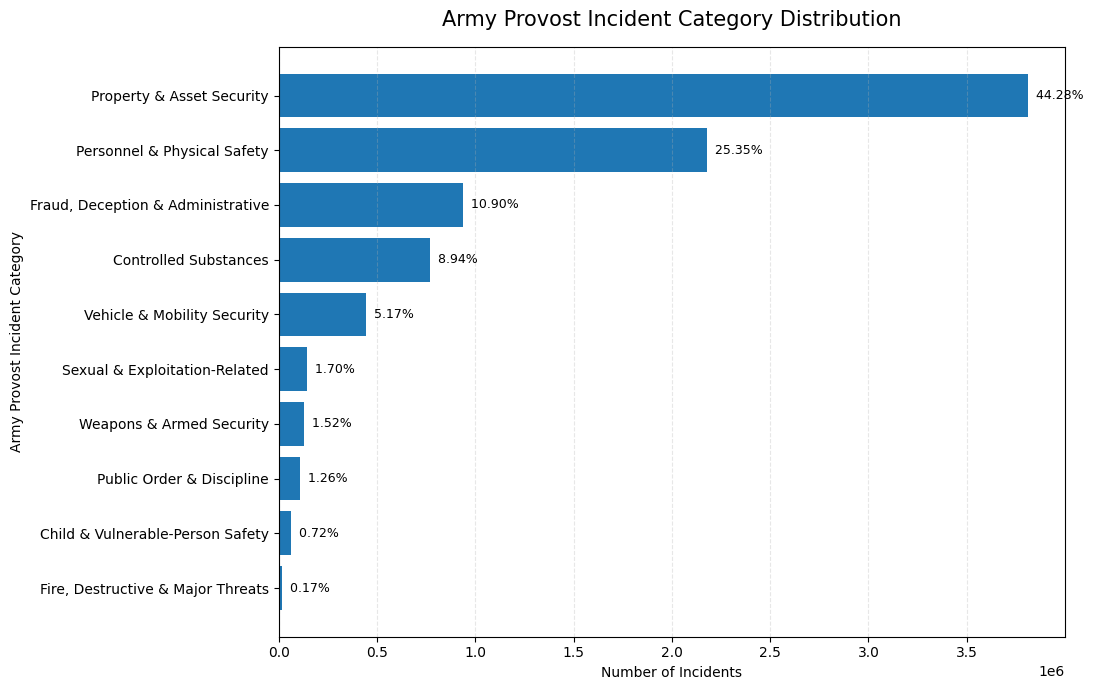


CATEGORY SUMMARY


,Provost Incident Category,Incident Count,Percentage
0,"Fire, Destructive & Major Threats","14,685",0.17%
1,Child & Vulnerable-Person Safety,"61,790",0.72%
2,Public Order & Discipline,"108,119",1.26%
3,Weapons & Armed Security,"130,400",1.52%
4,Sexual & Exploitation-Related,"146,231",1.70%
5,Vehicle & Mobility Security,"444,725",5.17%
6,Controlled Substances,"768,871",8.94%
7,"Fraud, Deception & Administrative","937,639",10.90%
8,Personnel & Physical Safety,"2,181,134",25.35%
9,Property & Asset Security,"3,809,140",44.28%



FILES SAVED

Category summary:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Army_Provost_Category_Summary.csv

Figure:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Army_Provost_Incident_Category_Distribution.png


In [5]:
# ============================================================
# ARMY PROVOST INCIDENT CATEGORY DISTRIBUTION
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("ARMY PROVOST INCIDENT CATEGORY DISTRIBUTION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Recreate project paths
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"

CATEGORY_DISTRIBUTION_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "Army_Provost_Category_Distribution.csv"
)

FIGURE_PATH = os.path.join(
    PROJECT_ROOT,
    "Figures",
    "Army_Provost_Incident_Category_Distribution.png"
)

# ------------------------------------------------------------
# 2. Load previously generated category distribution
# ------------------------------------------------------------

if not os.path.exists(CATEGORY_DISTRIBUTION_PATH):
    raise FileNotFoundError(
        f"Category distribution file not found:\n"
        f"{CATEGORY_DISTRIBUTION_PATH}"
    )

category_df = pd.read_csv(CATEGORY_DISTRIBUTION_PATH)

# ------------------------------------------------------------
# 3. Aggregate across priority levels
# ------------------------------------------------------------

category_summary = (
    category_df
    .groupby("Provost Incident Category", as_index=False)
    ["Incident Count"]
    .sum()
    .sort_values("Incident Count", ascending=True)
    .reset_index(drop=True)
)

total_incidents = category_summary["Incident Count"].sum()

category_summary["Percentage"] = (
    category_summary["Incident Count"]
    / total_incidents
    * 100
)

# ------------------------------------------------------------
# 4. Save aggregated summary
# ------------------------------------------------------------

CATEGORY_SUMMARY_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "Army_Provost_Category_Summary.csv"
)

category_summary.to_csv(
    CATEGORY_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------
# 5. Create visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

bars = plt.barh(
    category_summary["Provost Incident Category"],
    category_summary["Incident Count"]
)

plt.xlabel("Number of Incidents")
plt.ylabel("Army Provost Incident Category")
plt.title(
    "Army Provost Incident Category Distribution",
    fontsize=15,
    pad=15
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Add percentage labels
for bar, percentage in zip(
    bars,
    category_summary["Percentage"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {percentage:.2f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()

# ------------------------------------------------------------
# 6. Save figure
# ------------------------------------------------------------

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 7. Print summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CATEGORY SUMMARY")
print("=" * 70)

display(
    category_summary.style.format({
        "Incident Count": "{:,.0f}",
        "Percentage": "{:.2f}%"
    })
)

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(f"\nCategory summary:")
print(CATEGORY_SUMMARY_PATH)

print(f"\nFigure:")
print(FIGURE_PATH)

## Army Provost Incident Priority Distribution

The validated incident taxonomy assigns each source crime category an
operational priority level: Critical, High, Moderate, or Low.

This analysis measures the overall distribution of incidents across
these priority levels and establishes the baseline priority profile
for the Army Provost decision-support system.

ARMY PROVOST INCIDENT PRIORITY DISTRIBUTION


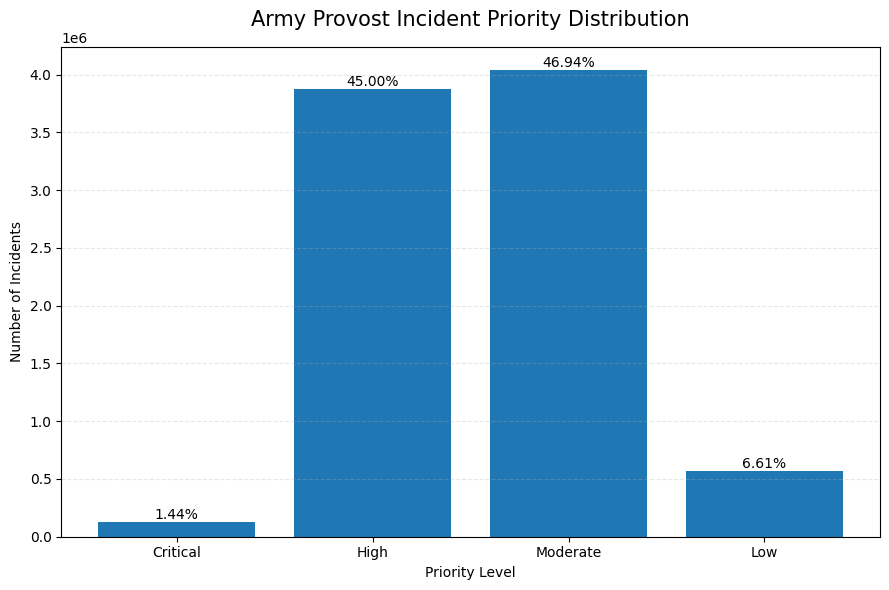


PRIORITY SUMMARY


,Priority Relevance,Incident Count,Percentage
0,Critical,"124,051",1.44%
1,High,"3,871,365",45.00%
2,Moderate,"4,038,292",46.94%
3,Low,"569,026",6.61%



FILES SAVED

Priority summary:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Army_Provost_Priority_Distribution.csv

Figure:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Army_Provost_Priority_Distribution.png


In [6]:
# ============================================================
# ARMY PROVOST INCIDENT PRIORITY DISTRIBUTION
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("ARMY PROVOST INCIDENT PRIORITY DISTRIBUTION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Project paths
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"

CATEGORY_DISTRIBUTION_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "Army_Provost_Category_Distribution.csv"
)

OUTPUT_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "Army_Provost_Priority_Distribution.csv"
)

FIGURE_PATH = os.path.join(
    PROJECT_ROOT,
    "Figures",
    "Army_Provost_Priority_Distribution.png"
)

# ------------------------------------------------------------
# 2. Verify input
# ------------------------------------------------------------

if not os.path.exists(CATEGORY_DISTRIBUTION_PATH):
    raise FileNotFoundError(
        f"Required file not found:\n"
        f"{CATEGORY_DISTRIBUTION_PATH}"
    )

# ------------------------------------------------------------
# 3. Load category-level distribution
# ------------------------------------------------------------

category_df = pd.read_csv(
    CATEGORY_DISTRIBUTION_PATH
)

# ------------------------------------------------------------
# 4. Aggregate by priority
# ------------------------------------------------------------

priority_summary = (
    category_df
    .groupby("Priority Relevance", as_index=False)
    ["Incident Count"]
    .sum()
)

# ------------------------------------------------------------
# 5. Enforce logical priority order
# ------------------------------------------------------------

priority_order = [
    "Critical",
    "High",
    "Moderate",
    "Low"
]

priority_summary["Priority Relevance"] = pd.Categorical(
    priority_summary["Priority Relevance"],
    categories=priority_order,
    ordered=True
)

priority_summary = (
    priority_summary
    .sort_values("Priority Relevance")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Calculate percentages
# ------------------------------------------------------------

total_incidents = priority_summary["Incident Count"].sum()

priority_summary["Percentage"] = (
    priority_summary["Incident Count"]
    / total_incidents
    * 100
)

# ------------------------------------------------------------
# 7. Save summary
# ------------------------------------------------------------

priority_summary.to_csv(
    OUTPUT_PATH,
    index=False
)

# ------------------------------------------------------------
# 8. Create visualization
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

bars = plt.bar(
    priority_summary["Priority Relevance"].astype(str),
    priority_summary["Incident Count"]
)

plt.xlabel("Priority Level")
plt.ylabel("Number of Incidents")
plt.title(
    "Army Provost Incident Priority Distribution",
    fontsize=15,
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Add percentage labels
for bar, percentage in zip(
    bars,
    priority_summary["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

# ------------------------------------------------------------
# 9. Save figure
# ------------------------------------------------------------

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 10. Display summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PRIORITY SUMMARY")
print("=" * 70)

display(
    priority_summary.style.format({
        "Incident Count": "{:,.0f}",
        "Percentage": "{:.2f}%"
    })
)

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(f"\nPriority summary:")
print(OUTPUT_PATH)

print(f"\nFigure:")
print(FIGURE_PATH)

## Operational Response Mapping

This section establishes the decision-support layer that connects
Army Provost incident categories and priority levels to recommended
response types.

The mapping is rule-based and transparent. It is not an ML prediction.
Its purpose is to transform incident classification and priority
information into an operationally interpretable recommendation for
the future decision-support dashboard.

In [7]:
# ============================================================
# OPERATIONAL RESPONSE MAPPING
# ============================================================

import pandas as pd
from pathlib import Path

print("=" * 70)
print("ARMY PROVOST OPERATIONAL RESPONSE MAPPING")
print("=" * 70)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Army_Provost_ML_Project"
)

OUTPUTS_PATH = PROJECT_ROOT / "Outputs"
FIGURES_PATH = PROJECT_ROOT / "Figures"

TAXONOMY_PATH = OUTPUTS_PATH / "Army_Provost_Incident_Taxonomy.csv"

# ------------------------------------------------------------
# Load validated taxonomy
# ------------------------------------------------------------

if not TAXONOMY_PATH.exists():
    raise FileNotFoundError(
        f"Validated taxonomy not found:\n{TAXONOMY_PATH}"
    )

taxonomy_df = pd.read_csv(TAXONOMY_PATH)

print(f"\nTaxonomy records loaded: {len(taxonomy_df):,}")

# ------------------------------------------------------------
# Define operational response types
# ------------------------------------------------------------

response_mapping = {

    "Personnel & Physical Safety":
        "Personnel Safety / Provost Response",

    "Property & Asset Security":
        "Property / Asset Security Response",

    "Controlled Substances":
        "Controlled Substances / Security Response",

    "Fraud, Deception & Administrative":
        "Administrative / Investigation Response",

    "Vehicle & Mobility Security":
        "Vehicle / Mobility Security Response",

    "Weapons & Armed Security":
        "Weapons / Security Response",

    "Public Order & Discipline":
        "Public Order / Discipline Response",

    "Sexual & Exploitation-Related":
        "Sensitive Incident / Specialized Response",

    "Child & Vulnerable-Person Safety":
        "Vulnerable-Person Protection / Specialized Response",

    "Fire, Destructive & Major Threats":
        "Fire / Major Threat Response"
}

# ------------------------------------------------------------
# Map response type
# ------------------------------------------------------------

taxonomy_df["Recommended Response Type"] = (
    taxonomy_df["Provost Incident Category"]
    .map(response_mapping)
)

# ------------------------------------------------------------
# Validate mapping
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESPONSE MAPPING VALIDATION")
print("=" * 70)

unmapped = taxonomy_df[
    taxonomy_df["Recommended Response Type"].isna()
]

if len(unmapped) == 0:
    print("\n✓ All taxonomy categories have a response type.")
else:
    print(
        f"\n✗ Unmapped categories: {len(unmapped)}"
    )
    print(
        unmapped[
            [
                "Primary Type",
                "Provost Incident Category"
            ]
        ]
    )

# ------------------------------------------------------------
# Display mapping
# ------------------------------------------------------------

response_mapping_df = taxonomy_df[
    [
        "Primary Type",
        "Provost Incident Category",
        "Incident Subcategory",
        "Priority Relevance",
        "Recommended Response Type"
    ]
].copy()

print("\n" + "=" * 70)
print("OPERATIONAL RESPONSE MAPPING")
print("=" * 70)

print(
    response_mapping_df.to_string(index=False)
)

# ------------------------------------------------------------
# Save mapping
# ------------------------------------------------------------

response_mapping_path = (
    OUTPUTS_PATH /
    "Army_Provost_Operational_Response_Mapping.csv"
)

response_mapping_df.to_csv(
    response_mapping_path,
    index=False
)

print("\n" + "=" * 70)
print("RESPONSE MAPPING SAVED")
print("=" * 70)

print(f"\nSaved to:")
print(response_mapping_path)

print("\n✓ OPERATIONAL RESPONSE MAPPING COMPLETED")

ARMY PROVOST OPERATIONAL RESPONSE MAPPING

Taxonomy records loaded: 34

RESPONSE MAPPING VALIDATION

✓ All taxonomy categories have a response type.

OPERATIONAL RESPONSE MAPPING
                     Primary Type         Provost Incident Category              Incident Subcategory Priority Relevance                           Recommended Response Type
                            THEFT         Property & Asset Security             Theft / Property Loss           Moderate                  Property / Asset Security Response
                          BATTERY       Personnel & Physical Safety                  Physical Assault               High                 Personnel Safety / Provost Response
                  CRIMINAL DAMAGE         Property & Asset Security                   Property Damage           Moderate                  Property / Asset Security Response
                        NARCOTICS             Controlled Substances                Narcotics Activity               High         

## Operational Response Distribution

This section summarizes the expected operational response types across
the mapped incident taxonomy.

The distribution is derived from the validated Army Provost taxonomy
and the incident-level category distribution. It provides an overview
of the types of response pathways that the future decision-support
dashboard may need to support.

ARMY PROVOST OPERATIONAL RESPONSE DISTRIBUTION

Operational mapping records : 34
Category distribution rows  : 16

MAPPING VALIDATION

✓ All incident categories mapped to response types.

OPERATIONAL RESPONSE SUMMARY
                          Recommended Response Type Incident Count Percentage
                 Property / Asset Security Response      3,809,140     44.28%
                Personnel Safety / Provost Response      2,181,134     25.35%
            Administrative / Investigation Response        937,639     10.90%
          Controlled Substances / Security Response        768,871      8.94%
               Vehicle / Mobility Security Response        444,725      5.17%
          Sensitive Incident / Specialized Response        146,231      1.70%
                        Weapons / Security Response        130,400      1.52%
                 Public Order / Discipline Response        108,119      1.26%
Vulnerable-Person Protection / Specialized Response         61,790      0.72%
   

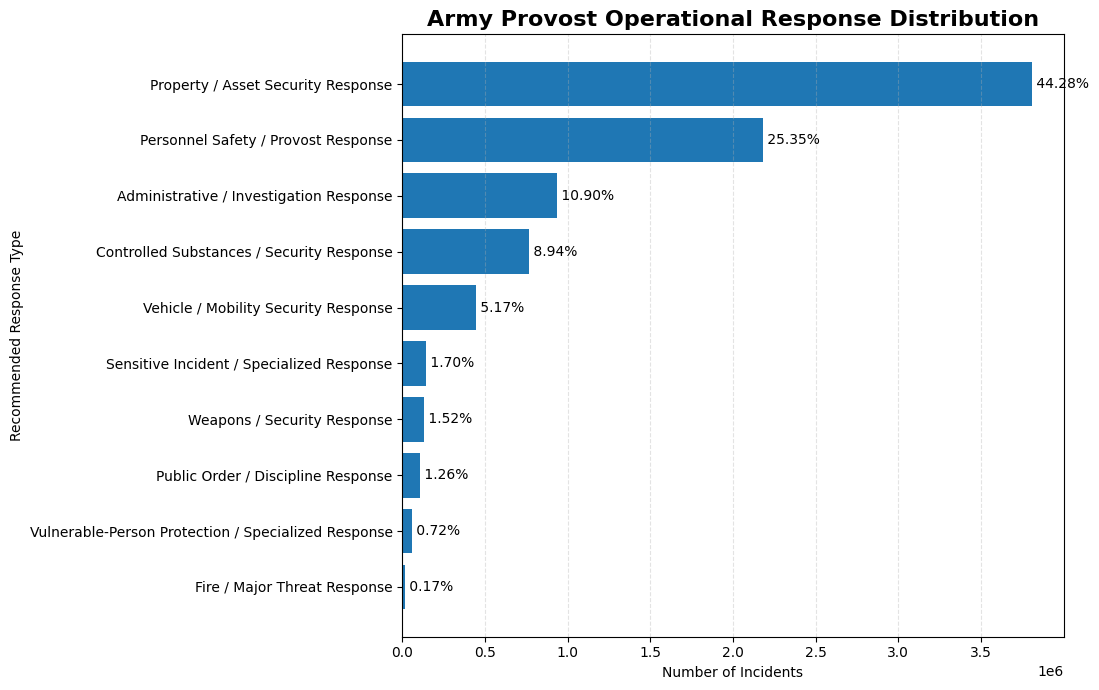


Figure saved to:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Army_Provost_Operational_Response_Distribution.png

OPERATIONAL RESPONSE DISTRIBUTION COMPLETED


In [8]:
# ============================================================
# OPERATIONAL RESPONSE DISTRIBUTION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 70)
print("ARMY PROVOST OPERATIONAL RESPONSE DISTRIBUTION")
print("=" * 70)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Army_Provost_ML_Project"
)

OUTPUTS_PATH = PROJECT_ROOT / "Outputs"
FIGURES_PATH = PROJECT_ROOT / "Figures"

# ------------------------------------------------------------
# Required files
# ------------------------------------------------------------

taxonomy_path = (
    OUTPUTS_PATH /
    "Army_Provost_Operational_Response_Mapping.csv"
)

category_distribution_path = (
    OUTPUTS_PATH /
    "Army_Provost_Category_Distribution.csv"
)

if not taxonomy_path.exists():
    raise FileNotFoundError(
        f"Operational response mapping not found:\n{taxonomy_path}"
    )

if not category_distribution_path.exists():
    raise FileNotFoundError(
        f"Category distribution not found:\n"
        f"{category_distribution_path}"
    )

# ------------------------------------------------------------
# Load files
# ------------------------------------------------------------

response_mapping_df = pd.read_csv(
    taxonomy_path
)

category_distribution_df = pd.read_csv(
    category_distribution_path
)

print("\nOperational mapping records :",
      len(response_mapping_df))

print("Category distribution rows  :",
      len(category_distribution_df))

# ------------------------------------------------------------
# Create category → response lookup
# ------------------------------------------------------------

category_response_lookup = (
    response_mapping_df[
        [
            "Provost Incident Category",
            "Recommended Response Type"
        ]
    ]
    .drop_duplicates()
)

# ------------------------------------------------------------
# Merge incident distribution with response type
# ------------------------------------------------------------

response_distribution = category_distribution_df.merge(
    category_response_lookup,
    on="Provost Incident Category",
    how="left"
)

# ------------------------------------------------------------
# Validate mapping
# ------------------------------------------------------------

unmapped = response_distribution[
    response_distribution["Recommended Response Type"].isna()
]

print("\n" + "=" * 70)
print("MAPPING VALIDATION")
print("=" * 70)

if len(unmapped) == 0:
    print("\n✓ All incident categories mapped to response types.")
else:
    print(
        f"\n✗ Unmapped distribution records: {len(unmapped)}"
    )
    print(unmapped)

# ------------------------------------------------------------
# Aggregate by response type
# ------------------------------------------------------------

operational_response_summary = (
    response_distribution
    .groupby("Recommended Response Type", as_index=False)
    ["Incident Count"]
    .sum()
)

# ------------------------------------------------------------
# Calculate percentages
# ------------------------------------------------------------

total_incidents = operational_response_summary[
    "Incident Count"
].sum()

operational_response_summary[
    "Percentage"
] = (
    operational_response_summary["Incident Count"]
    / total_incidents
    * 100
)

# ------------------------------------------------------------
# Sort descending
# ------------------------------------------------------------

operational_response_summary = (
    operational_response_summary
    .sort_values(
        "Incident Count",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OPERATIONAL RESPONSE SUMMARY")
print("=" * 70)

display_summary = operational_response_summary.copy()

display_summary["Incident Count"] = (
    display_summary["Incident Count"]
    .map(lambda x: f"{x:,}")
)

display_summary["Percentage"] = (
    display_summary["Percentage"]
    .map(lambda x: f"{x:.2f}%")
)

print(
    display_summary.to_string(index=False)
)

print(
    f"\nTotal incidents represented: "
    f"{total_incidents:,}"
)

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

response_distribution_path = (
    OUTPUTS_PATH /
    "Army_Provost_Operational_Response_Distribution.csv"
)

operational_response_summary.to_csv(
    response_distribution_path,
    index=False
)

print("\n" + "=" * 70)
print("SUMMARY SAVED")
print("=" * 70)

print(f"\nSaved to:")
print(response_distribution_path)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plot_df = operational_response_summary.sort_values(
    "Incident Count",
    ascending=True
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    plot_df["Recommended Response Type"],
    plot_df["Incident Count"]
)

plt.xlabel("Number of Incidents")
plt.ylabel("Recommended Response Type")
plt.title(
    "Army Provost Operational Response Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

# Add percentage labels
for bar, percentage in zip(
    bars,
    plot_df["Percentage"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {percentage:.2f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

response_distribution_figure = (
    FIGURES_PATH /
    "Army_Provost_Operational_Response_Distribution.png"
)

plt.savefig(
    response_distribution_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(response_distribution_figure)

print("\n" + "=" * 70)
print("OPERATIONAL RESPONSE DISTRIBUTION COMPLETED")
print("=" * 70)

# Army Provost Incident Decision Engine — Prototype

## Objective

This section develops the first standalone prototype of the Army Provost
Incident Decision Engine.

The engine will combine the already-completed project components:

1. Incident / Crime Type
2. Army Provost Incident Category
3. Incident Subcategory
4. Priority
5. Random Forest Arrest Probability
6. Recommended Operational Response
7. Operator-oriented Decision-Support Summary

The Random Forest model remains the official ML model for the
arrest-prediction component, with the established decision threshold of 0.50.

This prototype is a **decision-support layer**, not an autonomous command
system. It will recommend an appropriate response pathway for an operator;
it will not claim to deploy or command real-world Army personnel.

The implementation will reuse the existing saved model, preprocessing
pipeline, and taxonomy/response artifacts rather than retraining or
recreating completed components.

### Existing project artifacts used

- `final_random_forest.pkl`
- `preprocessing_pipeline.pkl`
- `Army_Provost_Incident_Taxonomy.csv`
- `Army_Provost_Operational_Response_Mapping.csv`

The engine will initially be designed as a reusable function so that the
same logic can later be connected to a dashboard.

In [9]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 1 — LOAD EXISTING PROJECT ARTIFACTS
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Existing project paths — DO NOT CHANGE
# ------------------------------------------------------------

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"

MODELS_PATH = os.path.join(PROJECT_ROOT, "Models")
OUTPUTS_PATH = os.path.join(PROJECT_ROOT, "Outputs")
FIGURES_PATH = os.path.join(PROJECT_ROOT, "Figures")
REPORTS_PATH = os.path.join(PROJECT_ROOT, "Reports")
CLEANED_DATA_PATH = os.path.join(PROJECT_ROOT, "Datasets", "Cleaned")

# ------------------------------------------------------------
# 2. Existing saved ML artifacts
# ------------------------------------------------------------

MODEL_PATH = os.path.join(
    MODELS_PATH,
    "final_random_forest.pkl"
)

PREPROCESSING_PATH = os.path.join(
    MODELS_PATH,
    "preprocessing_pipeline.pkl"
)

# ------------------------------------------------------------
# 3. Existing Decision-Support artifacts
# ------------------------------------------------------------

TAXONOMY_PATH = os.path.join(
    OUTPUTS_PATH,
    "Army_Provost_Incident_Taxonomy.csv"
)

RESPONSE_MAPPING_PATH = os.path.join(
    OUTPUTS_PATH,
    "Army_Provost_Operational_Response_Mapping.csv"
)

# ------------------------------------------------------------
# 4. Load the already-trained Random Forest
# ------------------------------------------------------------

final_rf_model = joblib.load(MODEL_PATH)

# ------------------------------------------------------------
# 5. Load the existing preprocessing pipeline
# ------------------------------------------------------------

preprocessing_pipeline = joblib.load(PREPROCESSING_PATH)

# ------------------------------------------------------------
# 6. Load the completed Army Provost taxonomy
# ------------------------------------------------------------

incident_taxonomy = pd.read_csv(TAXONOMY_PATH)

# ------------------------------------------------------------
# 7. Load the completed operational response mapping
# ------------------------------------------------------------

response_mapping = pd.read_csv(RESPONSE_MAPPING_PATH)

print("=" * 70)
print("ARMY PROVOST DECISION ENGINE — COMPONENTS LOADED")
print("=" * 70)

print("\n✓ Random Forest model loaded")
print(f"  Model: {type(final_rf_model).__name__}")

print("\n✓ Preprocessing pipeline loaded")
print(f"  Pipeline: {type(preprocessing_pipeline).__name__}")

print("\n✓ Incident taxonomy loaded")
print(f"  Rows: {len(incident_taxonomy):,}")

print("\n✓ Operational response mapping loaded")
print(f"  Rows: {len(response_mapping):,}")

print("\n✓ Existing project paths preserved")
print(f"  Project root: {PROJECT_ROOT}")

print("\n" + "=" * 70)

ARMY PROVOST DECISION ENGINE — COMPONENTS LOADED

✓ Random Forest model loaded
  Model: RandomForestClassifier

✓ Preprocessing pipeline loaded
  Pipeline: ColumnTransformer

✓ Incident taxonomy loaded
  Rows: 34

✓ Operational response mapping loaded
  Rows: 34

✓ Existing project paths preserved
  Project root: /content/drive/MyDrive/Army_Provost_ML_Project



In [10]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 2 — BUILD LOOKUP TABLES
# ============================================================

# ------------------------------------------------------------
# Inspect the exact column names of the existing artifacts
# ------------------------------------------------------------

print("=" * 70)
print("TAXONOMY AND RESPONSE MAPPING STRUCTURE")
print("=" * 70)

print("\nIncident Taxonomy Columns:")
print(incident_taxonomy.columns.tolist())

print("\nOperational Response Mapping Columns:")
print(response_mapping.columns.tolist())

print("\n" + "=" * 70)

# ------------------------------------------------------------
# Create normalized lookup keys
# ------------------------------------------------------------

incident_taxonomy["_lookup_key"] = (
    incident_taxonomy["Primary Type"]
    .astype(str)
    .str.strip()
    .str.upper()
)

response_mapping["_lookup_key"] = (
    response_mapping["Primary Type"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# ------------------------------------------------------------
# Create dictionary-based lookup structures
# ------------------------------------------------------------

taxonomy_lookup = (
    incident_taxonomy
    .set_index("_lookup_key")
    .to_dict(orient="index")
)

response_lookup = (
    response_mapping
    .set_index("_lookup_key")
    .to_dict(orient="index")
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("Taxonomy lookup entries :", len(taxonomy_lookup))
print("Response lookup entries :", len(response_lookup))

print("\nExpected taxonomy entries : 34")
print("Expected response entries : 34")

print("\nValidation:")

if len(taxonomy_lookup) == 34:
    print("✓ Taxonomy lookup contains all 34 incident types")
else:
    print("⚠ Taxonomy lookup count differs from expected 34")

if len(response_lookup) == 34:
    print("✓ Response lookup contains all 34 incident types")
else:
    print("⚠ Response lookup count differs from expected 34")

taxonomy_keys = set(taxonomy_lookup.keys())
response_keys = set(response_lookup.keys())

if taxonomy_keys == response_keys:
    print("✓ Taxonomy and response mappings contain identical incident types")
else:
    print("⚠ Taxonomy and response mappings do not contain identical incident types")

print("\n" + "=" * 70)

TAXONOMY AND RESPONSE MAPPING STRUCTURE

Incident Taxonomy Columns:
['Primary Type', 'Provost Incident Category', 'Incident Subcategory', 'Priority Relevance', 'Mapping Rationale']

Operational Response Mapping Columns:
['Primary Type', 'Provost Incident Category', 'Incident Subcategory', 'Priority Relevance', 'Recommended Response Type']

Taxonomy lookup entries : 34
Response lookup entries : 34

Expected taxonomy entries : 34
Expected response entries : 34

Validation:
✓ Taxonomy lookup contains all 34 incident types
✓ Response lookup contains all 34 incident types
✓ Taxonomy and response mappings contain identical incident types



In [11]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 3 — CORE INCIDENT DECISION FUNCTION
# ============================================================

def classify_army_provost_incident(primary_type):
    """
    Classify a police/crime incident into the established
    Army Provost decision-support taxonomy.

    Parameters
    ----------
    primary_type : str
        Chicago Crimes 'Primary Type' value.

    Returns
    -------
    dict
        Structured Army Provost decision-support information.
    """

    # --------------------------------------------------------
    # Normalize incoming incident type
    # --------------------------------------------------------

    if primary_type is None:
        raise ValueError("Primary Type cannot be None.")

    lookup_key = str(primary_type).strip().upper()

    # --------------------------------------------------------
    # Verify that the incident exists in the validated taxonomy
    # --------------------------------------------------------

    if lookup_key not in taxonomy_lookup:
        raise ValueError(
            f"Incident type '{primary_type}' is not present "
            f"in the validated Army Provost taxonomy."
        )

    # --------------------------------------------------------
    # Retrieve taxonomy information
    # --------------------------------------------------------

    taxonomy_info = taxonomy_lookup[lookup_key]

    # --------------------------------------------------------
    # Retrieve operational response information
    # --------------------------------------------------------

    response_info = response_lookup[lookup_key]

    # --------------------------------------------------------
    # Construct structured decision-support output
    # --------------------------------------------------------

    decision = {
        "Primary Type": taxonomy_info["Primary Type"],
        "Provost Incident Category": taxonomy_info[
            "Provost Incident Category"
        ],
        "Incident Subcategory": taxonomy_info[
            "Incident Subcategory"
        ],
        "Priority Relevance": taxonomy_info[
            "Priority Relevance"
        ],
        "Recommended Response Type": response_info[
            "Recommended Response Type"
        ]
    }

    return decision


# ============================================================
# TEST THE FUNCTION WITH A KNOWN INCIDENT TYPE
# ============================================================

test_incident = classify_army_provost_incident("BATTERY")

print("=" * 70)
print("ARMY PROVOST INCIDENT CLASSIFICATION — TEST")
print("=" * 70)

for key, value in test_incident.items():
    print(f"{key}: {value}")

print("=" * 70)

ARMY PROVOST INCIDENT CLASSIFICATION — TEST
Primary Type: BATTERY
Provost Incident Category: Personnel & Physical Safety
Incident Subcategory: Physical Assault
Priority Relevance: High
Recommended Response Type: Personnel Safety / Provost Response


In [12]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 4 — MODEL FEATURE INTERFACE
# ============================================================

print("=" * 70)
print("RANDOM FOREST MODEL INTERFACE")
print("=" * 70)

# ------------------------------------------------------------
# Model information
# ------------------------------------------------------------

print("\nModel type:")
print(type(final_rf_model).__name__)

print("\nNumber of features expected by Random Forest:")
print(final_rf_model.n_features_in_)

# ------------------------------------------------------------
# Inspect preprocessing pipeline structure
# ------------------------------------------------------------

print("\nPreprocessing pipeline:")
print(preprocessing_pipeline)

print("\nPreprocessing transformers:")

for name, transformer, columns in preprocessing_pipeline.transformers_:
    print(f"\n{name}")
    print(f"Columns: {columns}")

# ------------------------------------------------------------
# If feature names are available, display them
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE NAME AVAILABILITY")
print("=" * 70)

if hasattr(preprocessing_pipeline, "get_feature_names_out"):
    try:
        processed_feature_names = (
            preprocessing_pipeline.get_feature_names_out()
        )

        print(
            f"\n✓ Processed feature names available: "
            f"{len(processed_feature_names)}"
        )

        print("\nFirst 20 processed features:")
        for feature in processed_feature_names[:20]:
            print(f"  - {feature}")

    except Exception as e:
        print("\n⚠ Feature names could not be extracted.")
        print(f"Reason: {e}")

else:
    print("\n⚠ Preprocessing pipeline does not expose feature names.")

print("\n" + "=" * 70)

RANDOM FOREST MODEL INTERFACE

Model type:
RandomForestClassifier

Number of features expected by Random Forest:
231

Preprocessing pipeline:
ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Primary Type', 'Location Description',
                                  'Domestic']),
                                ('numerical', 'passthrough',
                                 ['Year', 'Month', 'Day', 'Hour', 'District',
                                  'Beat', 'Ward', 'Community Area'])])

Preprocessing transformers:

categorical
Columns: ['Primary Type', 'Location Description', 'Domestic']

numerical
Columns: ['Year', 'Month', 'Day', 'Hour', 'District', 'Beat', 'Ward', 'Community Area']

FEATURE NAME AVAILABILITY

✓ Processed feature names available: 231

First 20 processed features:
  - categorical__Primary Type_ARSON
  - categorical__Primary Type_ASSAULT
  - categorical__Primary Type

In [13]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 5 — RANDOM FOREST ARREST PROBABILITY
# ============================================================

def predict_arrest_probability(
    primary_type,
    location_description,
    domestic,
    year,
    month,
    day,
    hour,
    district,
    beat,
    ward,
    community_area
):
    """
    Generate arrest probability using the existing
    Random Forest model and preprocessing pipeline.

    This function does NOT retrain the model.

    Parameters correspond exactly to the 11 original
    features used during ML modeling.
    """

    # --------------------------------------------------------
    # Create one-row input using the original feature schema
    # --------------------------------------------------------

    input_data = pd.DataFrame([{
        "Primary Type": primary_type,
        "Location Description": location_description,
        "Domestic": domestic,
        "Year": year,
        "Month": month,
        "Day": day,
        "Hour": hour,
        "District": district,
        "Beat": beat,
        "Ward": ward,
        "Community Area": community_area
    }])

    # --------------------------------------------------------
    # Apply the EXISTING preprocessing pipeline
    # --------------------------------------------------------

    processed_input = preprocessing_pipeline.transform(input_data)

    # --------------------------------------------------------
    # Verify processed feature count
    # --------------------------------------------------------

    if processed_input.shape[1] != final_rf_model.n_features_in_:
        raise ValueError(
            f"Processed input contains {processed_input.shape[1]} "
            f"features, but the Random Forest expects "
            f"{final_rf_model.n_features_in_}."
        )

    # --------------------------------------------------------
    # Generate probability
    # --------------------------------------------------------

    arrest_probability = final_rf_model.predict_proba(
        processed_input
    )[0, 1]

    # --------------------------------------------------------
    # Official project threshold remains 0.50
    # --------------------------------------------------------

    arrest_prediction = (
        "Likely Arrest"
        if arrest_probability >= 0.50
        else "Less Likely Arrest"
    )

    return {
        "Arrest Probability": float(arrest_probability),
        "Arrest Probability (%)": round(
            float(arrest_probability) * 100, 2
        ),
        "Arrest Prediction": arrest_prediction
    }


print("=" * 70)
print("RANDOM FOREST PREDICTION FUNCTION CREATED")
print("=" * 70)

print("\n✓ Uses existing preprocessing pipeline")
print("✓ Uses existing Random Forest model")
print("✓ No retraining performed")
print("✓ Input schema matches the original 11 ML features")
print(f"✓ Processed feature count: {final_rf_model.n_features_in_}")
print("✓ Official decision threshold: 0.50")

print("\n" + "=" * 70)

RANDOM FOREST PREDICTION FUNCTION CREATED

✓ Uses existing preprocessing pipeline
✓ Uses existing Random Forest model
✓ No retraining performed
✓ Input schema matches the original 11 ML features
✓ Processed feature count: 231
✓ Official decision threshold: 0.50



In [14]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 6 — ML PREDICTION TEST
# ============================================================

# ------------------------------------------------------------
# Example incident
# ------------------------------------------------------------
# This is a functional test of the prediction pipeline.
# The values are supplied directly to the already-trained model.

test_incident = {
    "Primary Type": "BATTERY",
    "Location Description": "STREET",
    "Domestic": False,
    "Year": 2025,
    "Month": 7,
    "Day": 15,
    "Hour": 20,
    "District": 1,
    "Beat": 100,
    "Ward": 1,
    "Community Area": 32
}

# ------------------------------------------------------------
# Generate arrest probability
# ------------------------------------------------------------

prediction_result = predict_arrest_probability(
    primary_type=test_incident["Primary Type"],
    location_description=test_incident["Location Description"],
    domestic=test_incident["Domestic"],
    year=test_incident["Year"],
    month=test_incident["Month"],
    day=test_incident["Day"],
    hour=test_incident["Hour"],
    district=test_incident["District"],
    beat=test_incident["Beat"],
    ward=test_incident["Ward"],
    community_area=test_incident["Community Area"]
)

# ------------------------------------------------------------
# Display input
# ------------------------------------------------------------

print("=" * 70)
print("ML PREDICTION TEST — INPUT INCIDENT")
print("=" * 70)

for key, value in test_incident.items():
    print(f"{key}: {value}")

# ------------------------------------------------------------
# Display prediction
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RANDOM FOREST OUTPUT")
print("=" * 70)

print(
    f"Arrest Probability: "
    f"{prediction_result['Arrest Probability (%)']:.2f}%"
)

print(
    f"Arrest Prediction: "
    f"{prediction_result['Arrest Prediction']}"
)

print("Decision Threshold: 50.00%")

print("\n" + "=" * 70)

ML PREDICTION TEST — INPUT INCIDENT
Primary Type: BATTERY
Location Description: STREET
Domestic: False
Year: 2025
Month: 7
Day: 15
Hour: 20
District: 1
Beat: 100
Ward: 1
Community Area: 32

RANDOM FOREST OUTPUT
Arrest Probability: 39.57%
Arrest Prediction: Less Likely Arrest
Decision Threshold: 50.00%



In [15]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 7 — INTEGRATED DECISION ENGINE
# ============================================================

def army_provost_decision_engine(
    primary_type,
    location_description,
    domestic,
    year,
    month,
    day,
    hour,
    district,
    beat,
    ward,
    community_area
):
    """
    Integrated Army Provost Decision-Support Engine.

    Combines:
        1. Army Provost incident taxonomy
        2. Priority classification
        3. Random Forest arrest probability
        4. Recommended operational response

    This is a decision-support prototype.
    It does not autonomously deploy or command personnel.
    """

    # ========================================================
    # STEP 1 — INCIDENT CLASSIFICATION
    # ========================================================

    classification = classify_army_provost_incident(
        primary_type
    )

    # ========================================================
    # STEP 2 — ML ARREST PROBABILITY
    # ========================================================

    ml_result = predict_arrest_probability(
        primary_type=primary_type,
        location_description=location_description,
        domestic=domestic,
        year=year,
        month=month,
        day=day,
        hour=hour,
        district=district,
        beat=beat,
        ward=ward,
        community_area=community_area
    )

    # ========================================================
    # STEP 3 — CONSTRUCT DECISION-SUPPORT OUTPUT
    # ========================================================

    decision = {
        # Incident information
        "Primary Type": classification["Primary Type"],
        "Location Description": location_description,
        "Domestic": domestic,

        # Army Provost classification
        "Provost Incident Category":
            classification["Provost Incident Category"],

        "Incident Subcategory":
            classification["Incident Subcategory"],

        "Priority":
            classification["Priority Relevance"],

        # ML information
        "Arrest Probability":
            ml_result["Arrest Probability"],

        "Arrest Probability (%)":
            ml_result["Arrest Probability (%)"],

        "Arrest Prediction":
            ml_result["Arrest Prediction"],

        # Operational response
        "Recommended Response Type":
            classification["Recommended Response Type"],

        # Contextual information
        "Year": year,
        "Month": month,
        "Day": day,
        "Hour": hour,
        "District": district,
        "Beat": beat,
        "Ward": ward,
        "Community Area": community_area
    }

    return decision


# ============================================================
# TEST THE COMPLETE DECISION ENGINE
# ============================================================

decision_result = army_provost_decision_engine(
    primary_type="BATTERY",
    location_description="STREET",
    domestic=False,
    year=2025,
    month=7,
    day=15,
    hour=20,
    district=1,
    beat=100,
    ward=1,
    community_area=32
)

# ============================================================
# DISPLAY INTEGRATED RESULT
# ============================================================

print("=" * 70)
print("ARMY PROVOST INCIDENT DECISION ENGINE")
print("=" * 70)

print("\nINCIDENT")
print("-" * 70)
print(f"Primary Type       : {decision_result['Primary Type']}")
print(f"Location           : {decision_result['Location Description']}")
print(f"Domestic           : {decision_result['Domestic']}")

print("\nARMY PROVOST CLASSIFICATION")
print("-" * 70)
print(
    f"Category           : "
    f"{decision_result['Provost Incident Category']}"
)
print(
    f"Subcategory        : "
    f"{decision_result['Incident Subcategory']}"
)
print(
    f"Priority           : "
    f"{decision_result['Priority']}"
)

print("\nML ASSESSMENT")
print("-" * 70)
print(
    f"Arrest Probability : "
    f"{decision_result['Arrest Probability (%)']:.2f}%"
)
print(
    f"Arrest Prediction  : "
    f"{decision_result['Arrest Prediction']}"
)
print("Decision Threshold : 50.00%")

print("\nRECOMMENDED RESPONSE")
print("-" * 70)
print(
    decision_result["Recommended Response Type"]
)

print("\n" + "=" * 70)
print("DECISION-SUPPORT STATUS")
print("=" * 70)

print(
    "✓ Incident classified"
)
print(
    "✓ Army Provost category assigned"
)
print(
    "✓ Priority assigned"
)
print(
    "✓ ML arrest probability generated"
)
print(
    "✓ Response pathway identified"
)
print(
    "✓ Output suitable for dashboard integration"
)

print("\nNote: This is a decision-support prototype.")
print(
    "It recommends a response pathway and does not "
    "autonomously deploy personnel."
)

print("=" * 70)

ARMY PROVOST INCIDENT DECISION ENGINE

INCIDENT
----------------------------------------------------------------------
Primary Type       : BATTERY
Location           : STREET
Domestic           : False

ARMY PROVOST CLASSIFICATION
----------------------------------------------------------------------
Category           : Personnel & Physical Safety
Subcategory        : Physical Assault
Priority           : High

ML ASSESSMENT
----------------------------------------------------------------------
Arrest Probability : 39.57%
Arrest Prediction  : Less Likely Arrest
Decision Threshold : 50.00%

RECOMMENDED RESPONSE
----------------------------------------------------------------------
Personnel Safety / Provost Response

DECISION-SUPPORT STATUS
✓ Incident classified
✓ Army Provost category assigned
✓ Priority assigned
✓ ML arrest probability generated
✓ Response pathway identified
✓ Output suitable for dashboard integration

Note: This is a decision-support prototype.
It recommends a resp

In [16]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 8 — OPERATOR DECISION-SUPPORT SUMMARY
# ============================================================

def generate_operator_summary(decision_result):
    """
    Convert the structured decision-engine output into a concise,
    human-readable operator decision-support summary.

    This is an advisory summary only.
    """

    summary = (
        f"INCIDENT: {decision_result['Primary Type']}\n"
        f"LOCATION: {decision_result['Location Description']}\n"
        f"DOMESTIC: {decision_result['Domestic']}\n\n"

        f"PROVOST CATEGORY: "
        f"{decision_result['Provost Incident Category']}\n"

        f"INCIDENT SUBCATEGORY: "
        f"{decision_result['Incident Subcategory']}\n"

        f"PRIORITY: {decision_result['Priority']}\n\n"

        f"ML ARREST PROBABILITY: "
        f"{decision_result['Arrest Probability (%)']:.2f}%\n"

        f"ML ASSESSMENT: "
        f"{decision_result['Arrest Prediction']}\n\n"

        f"RECOMMENDED RESPONSE PATHWAY: "
        f"{decision_result['Recommended Response Type']}\n\n"

        f"OPERATOR NOTE: "
        f"This output is a decision-support recommendation. "
        f"Final operational decisions remain with the authorized operator."
    )

    return summary


# ============================================================
# GENERATE SUMMARY FOR THE TEST INCIDENT
# ============================================================

operator_summary = generate_operator_summary(
    decision_result
)

print("=" * 70)
print("ARMY PROVOST — OPERATOR DECISION-SUPPORT SUMMARY")
print("=" * 70)
print()
print(operator_summary)
print()
print("=" * 70)

ARMY PROVOST — OPERATOR DECISION-SUPPORT SUMMARY

INCIDENT: BATTERY
LOCATION: STREET
DOMESTIC: False

PROVOST CATEGORY: Personnel & Physical Safety
INCIDENT SUBCATEGORY: Physical Assault
PRIORITY: High

ML ARREST PROBABILITY: 39.57%
ML ASSESSMENT: Less Likely Arrest

RECOMMENDED RESPONSE PATHWAY: Personnel Safety / Provost Response

OPERATOR NOTE: This output is a decision-support recommendation. Final operational decisions remain with the authorized operator.



In [17]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 9 — MULTI-INCIDENT VALIDATION
# ============================================================

# A small representative test set covering different
# Army Provost-oriented categories.

test_incidents = [
    {
        "Primary Type": "THEFT",
        "Location Description": "STREET",
        "Domestic": False,
        "Year": 2025,
        "Month": 7,
        "Day": 15,
        "Hour": 14,
        "District": 1,
        "Beat": 100,
        "Ward": 1,
        "Community Area": 32
    },
    {
        "Primary Type": "BATTERY",
        "Location Description": "STREET",
        "Domestic": False,
        "Year": 2025,
        "Month": 7,
        "Day": 15,
        "Hour": 20,
        "District": 1,
        "Beat": 100,
        "Ward": 1,
        "Community Area": 32
    },
    {
        "Primary Type": "NARCOTICS",
        "Location Description": "STREET",
        "Domestic": False,
        "Year": 2025,
        "Month": 7,
        "Day": 16,
        "Hour": 22,
        "District": 1,
        "Beat": 100,
        "Ward": 1,
        "Community Area": 32
    },
    {
        "Primary Type": "WEAPONS VIOLATION",
        "Location Description": "STREET",
        "Domestic": False,
        "Year": 2025,
        "Month": 7,
        "Day": 17,
        "Hour": 23,
        "District": 1,
        "Beat": 100,
        "Ward": 1,
        "Community Area": 32
    },
    {
        "Primary Type": "HOMICIDE",
        "Location Description": "STREET",
        "Domestic": False,
        "Year": 2025,
        "Month": 7,
        "Day": 18,
        "Hour": 1,
        "District": 1,
        "Beat": 100,
        "Ward": 1,
        "Community Area": 32
    },
    {
        "Primary Type": "ARSON",
        "Location Description": "STREET",
        "Domestic": False,
        "Year": 2025,
        "Month": 7,
        "Day": 19,
        "Hour": 2,
        "District": 1,
        "Beat": 100,
        "Ward": 1,
        "Community Area": 32
    }
]

# ------------------------------------------------------------
# Run every incident through the complete engine
# ------------------------------------------------------------

validation_results = []

for incident in test_incidents:

    result = army_provost_decision_engine(
        primary_type=incident["Primary Type"],
        location_description=incident["Location Description"],
        domestic=incident["Domestic"],
        year=incident["Year"],
        month=incident["Month"],
        day=incident["Day"],
        hour=incident["Hour"],
        district=incident["District"],
        beat=incident["Beat"],
        ward=incident["Ward"],
        community_area=incident["Community Area"]
    )

    validation_results.append(result)

# ------------------------------------------------------------
# Convert results to a DataFrame
# ------------------------------------------------------------

validation_df = pd.DataFrame(validation_results)

# ------------------------------------------------------------
# Display important decision-support fields
# ------------------------------------------------------------

display_columns = [
    "Primary Type",
    "Provost Incident Category",
    "Incident Subcategory",
    "Priority",
    "Arrest Probability (%)",
    "Arrest Prediction",
    "Recommended Response Type"
]

print("=" * 120)
print("MULTI-INCIDENT DECISION ENGINE VALIDATION")
print("=" * 120)

display(
    validation_df[display_columns]
)

# ------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)

print(
    f"\n✓ Incidents tested: "
    f"{len(validation_df)}"
)

print(
    f"✓ Successful classifications: "
    f"{validation_df['Provost Incident Category'].notna().sum()}"
)

print(
    f"✓ Priority values generated: "
    f"{validation_df['Priority'].notna().sum()}"
)

print(
    f"✓ ML probabilities generated: "
    f"{validation_df['Arrest Probability (%)'].notna().sum()}"
)

print(
    f"✓ Response pathways generated: "
    f"{validation_df['Recommended Response Type'].notna().sum()}"
)

# ------------------------------------------------------------
# Final validation condition
# ------------------------------------------------------------

all_valid = (
    validation_df["Provost Incident Category"].notna().all()
    and
    validation_df["Incident Subcategory"].notna().all()
    and
    validation_df["Priority"].notna().all()
    and
    validation_df["Arrest Probability (%)"].notna().all()
    and
    validation_df["Recommended Response Type"].notna().all()
)

print()

if all_valid:
    print("✓ MULTI-INCIDENT VALIDATION PASSED")
    print("✓ All tested incidents completed the decision pipeline")
else:
    print("⚠ MULTI-INCIDENT VALIDATION REQUIRES REVIEW")

print("=" * 70)

MULTI-INCIDENT DECISION ENGINE VALIDATION


,Primary Type,Provost Incident Category,Incident Subcategory,Priority,Arrest Probability (%),Arrest Prediction,Recommended Response Type
0,THEFT,Property & Asset Security,Theft / Property Loss,Moderate,17.55,Less Likely Arrest,Property / Asset Security Response
1,BATTERY,Personnel & Physical Safety,Physical Assault,High,39.57,Less Likely Arrest,Personnel Safety / Provost Response
2,NARCOTICS,Controlled Substances,Narcotics Activity,High,91.21,Likely Arrest,Controlled Substances / Security Response
3,WEAPONS VIOLATION,Weapons & Armed Security,Weapons Violation,High,80.23,Likely Arrest,Weapons / Security Response
4,HOMICIDE,Personnel & Physical Safety,Fatal Violence,Critical,47.97,Less Likely Arrest,Personnel Safety / Provost Response
5,ARSON,"Fire, Destructive & Major Threats",Arson / Fire Threat,High,35.56,Less Likely Arrest,Fire / Major Threat Response



VALIDATION RESULTS

✓ Incidents tested: 6
✓ Successful classifications: 6
✓ Priority values generated: 6
✓ ML probabilities generated: 6
✓ Response pathways generated: 6

✓ MULTI-INCIDENT VALIDATION PASSED
✓ All tested incidents completed the decision pipeline


In [18]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 10 — SAVE VALIDATION ARTIFACT
# ============================================================

# ------------------------------------------------------------
# Output path — preserve existing project structure
# ------------------------------------------------------------

DECISION_ENGINE_VALIDATION_PATH = os.path.join(
    OUTPUTS_PATH,
    "Army_Provost_Decision_Engine_Validation.csv"
)

# ------------------------------------------------------------
# Save complete validation results
# ------------------------------------------------------------

validation_df.to_csv(
    DECISION_ENGINE_VALIDATION_PATH,
    index=False
)

# ------------------------------------------------------------
# Print confirmation and summary
# ------------------------------------------------------------

print("=" * 70)
print("DECISION ENGINE VALIDATION ARTIFACT SAVED")
print("=" * 70)

print(
    f"\nSaved to:\n{DECISION_ENGINE_VALIDATION_PATH}"
)

print(
    f"\nRecords saved: {len(validation_df):,}"
)

print(
    f"Columns saved: {len(validation_df.columns):,}"
)

print("\nValidation status:")
print("✓ All 6 test incidents successfully processed")
print("✓ Classification results preserved")
print("✓ Priority results preserved")
print("✓ ML probability results preserved")
print("✓ Response recommendations preserved")

# ------------------------------------------------------------
# Verify file exists
# ------------------------------------------------------------

if os.path.exists(DECISION_ENGINE_VALIDATION_PATH):
    file_size_kb = (
        os.path.getsize(DECISION_ENGINE_VALIDATION_PATH) / 1024
    )

    print(
        f"\n✓ File verification successful"
        f"\n  Size: {file_size_kb:.2f} KB"
    )
else:
    print("\n⚠ File verification failed.")

print("\n" + "=" * 70)

DECISION ENGINE VALIDATION ARTIFACT SAVED

Saved to:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/Army_Provost_Decision_Engine_Validation.csv

Records saved: 6
Columns saved: 18

Validation status:
✓ All 6 test incidents successfully processed
✓ Classification results preserved
✓ Priority results preserved
✓ ML probability results preserved
✓ Response recommendations preserved

✓ File verification successful
  Size: 1.26 KB



In [19]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 11 — STANDARDIZED DECISION RECORD
# ============================================================

from datetime import datetime


def create_decision_record(decision_result):
    """
    Convert an existing decision-engine result into a
    standardized DSS decision record.

    This function does not change the underlying ML prediction,
    taxonomy, priority, or response mapping.
    """

    # --------------------------------------------------------
    # Generate a unique record identifier
    # --------------------------------------------------------

    decision_id = (
        "AP-DSS-"
        + datetime.now().strftime("%Y%m%d-%H%M%S-%f")
    )

    # --------------------------------------------------------
    # Record the current decision-generation timestamp
    # --------------------------------------------------------

    decision_timestamp = datetime.now().isoformat(
        timespec="seconds"
    )

    # --------------------------------------------------------
    # Create standardized record
    # --------------------------------------------------------

    decision_record = {
        "Decision ID": decision_id,
        "Decision Timestamp": decision_timestamp,

        "Primary Type": decision_result["Primary Type"],
        "Location Description": decision_result[
            "Location Description"
        ],
        "Domestic": decision_result["Domestic"],

        "Provost Incident Category": decision_result[
            "Provost Incident Category"
        ],
        "Incident Subcategory": decision_result[
            "Incident Subcategory"
        ],
        "Priority": decision_result["Priority"],

        "Arrest Probability": decision_result[
            "Arrest Probability"
        ],
        "Arrest Probability (%)": decision_result[
            "Arrest Probability (%)"
        ],
        "Arrest Prediction": decision_result[
            "Arrest Prediction"
        ],

        "Recommended Response Type": decision_result[
            "Recommended Response Type"
        ],

        "Year": decision_result["Year"],
        "Month": decision_result["Month"],
        "Day": decision_result["Day"],
        "Hour": decision_result["Hour"],
        "District": decision_result["District"],
        "Beat": decision_result["Beat"],
        "Ward": decision_result["Ward"],
        "Community Area": decision_result[
            "Community Area"
        ]
    }

    return decision_record


# ============================================================
# CREATE A STANDARDIZED RECORD FROM THE TEST INCIDENT
# ============================================================

decision_record = create_decision_record(
    decision_result
)

decision_record_df = pd.DataFrame(
    [decision_record]
)

# ============================================================
# DISPLAY STANDARDIZED RECORD
# ============================================================

print("=" * 70)
print("ARMY PROVOST — STANDARDIZED DECISION RECORD")
print("=" * 70)

display(decision_record_df.T)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    f"\n✓ Decision ID generated: "
    f"{decision_record['Decision ID']}"
)

print(
    f"✓ Decision timestamp: "
    f"{decision_record['Decision Timestamp']}"
)

print(
    f"✓ Total fields: "
    f"{len(decision_record)}"
)

print("\n✓ Existing taxonomy preserved")
print("✓ Existing priority preserved")
print("✓ Existing ML probability preserved")
print("✓ Existing response mapping preserved")
print("✓ No model retraining performed")

print("\n" + "=" * 70)

ARMY PROVOST — STANDARDIZED DECISION RECORD


,0
Decision ID,AP-DSS-20260809-053106-388437
Decision Timestamp,2026-08-09T05:31:06
Primary Type,BATTERY
Location Description,STREET
Domestic,False
Provost Incident Category,Personnel & Physical Safety
Incident Subcategory,Physical Assault
Priority,High
Arrest Probability,0.395685
Arrest Probability (%),39.57



VALIDATION

✓ Decision ID generated: AP-DSS-20260809-053106-388437
✓ Decision timestamp: 2026-08-09T05:31:06
✓ Total fields: 20

✓ Existing taxonomy preserved
✓ Existing priority preserved
✓ Existing ML probability preserved
✓ Existing response mapping preserved
✓ No model retraining performed



In [20]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 12 — DECISION INTERPRETATION
# ============================================================

def interpret_decision_record(decision_record):
    """
    Generate an operator-oriented interpretation of the
    decision-support signals.

    IMPORTANT:
    - Does NOT modify the official priority.
    - Does NOT modify the Random Forest threshold.
    - Does NOT create an autonomous operational command.
    """

    priority = decision_record["Priority"]
    arrest_probability = decision_record[
        "Arrest Probability (%)"
    ]
    arrest_prediction = decision_record[
        "Arrest Prediction"
    ]

    # --------------------------------------------------------
    # Interpret priority independently
    # --------------------------------------------------------

    priority_message = (
        f"Official incident priority is {priority}."
    )

    # --------------------------------------------------------
    # Interpret ML result independently
    # --------------------------------------------------------

    ml_message = (
        f"The Random Forest estimates an arrest probability "
        f"of {arrest_probability:.2f}% and classifies the "
        f"incident as '{arrest_prediction}'."
    )

    # --------------------------------------------------------
    # Explain relationship between signals
    # --------------------------------------------------------

    relationship_message = (
        "Priority and ML arrest probability are separate "
        "decision-support indicators. The ML result does not "
        "override the established incident priority."
    )

    # --------------------------------------------------------
    # Operational response interpretation
    # --------------------------------------------------------

    response_message = (
        f"The mapped response pathway is "
        f"'{decision_record['Recommended Response Type']}'. "
        "This is a recommendation for operator consideration, "
        "not an autonomous deployment decision."
    )

    # --------------------------------------------------------
    # Combined interpretation
    # --------------------------------------------------------

    interpretation = {
        "Priority Interpretation": priority_message,
        "ML Interpretation": ml_message,
        "Signal Relationship": relationship_message,
        "Response Interpretation": response_message
    }

    return interpretation


# ============================================================
# GENERATE INTERPRETATION
# ============================================================

decision_interpretation = interpret_decision_record(
    decision_record
)

# ============================================================
# DISPLAY
# ============================================================

print("=" * 70)
print("ARMY PROVOST — DECISION INTERPRETATION")
print("=" * 70)

for key, value in decision_interpretation.items():
    print(f"\n{key}")
    print("-" * 70)
    print(value)

print("\n" + "=" * 70)
print("INTERPRETATION VALIDATION")
print("=" * 70)

print("✓ Official priority preserved")
print("✓ ML probability preserved")
print("✓ ML threshold unchanged")
print("✓ Response recommendation preserved")
print("✓ No autonomous operational decision introduced")

print("\n" + "=" * 70)

ARMY PROVOST — DECISION INTERPRETATION

Priority Interpretation
----------------------------------------------------------------------
Official incident priority is High.

ML Interpretation
----------------------------------------------------------------------
The Random Forest estimates an arrest probability of 39.57% and classifies the incident as 'Less Likely Arrest'.

Signal Relationship
----------------------------------------------------------------------
Priority and ML arrest probability are separate decision-support indicators. The ML result does not override the established incident priority.

Response Interpretation
----------------------------------------------------------------------
The mapped response pathway is 'Personnel Safety / Provost Response'. This is a recommendation for operator consideration, not an autonomous deployment decision.

INTERPRETATION VALIDATION
✓ Official priority preserved
✓ ML probability preserved
✓ ML threshold unchanged
✓ Response recommendati

In [21]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 13 — REUSABLE DSS WRAPPER
# ============================================================

def run_army_provost_dss(
    primary_type,
    location_description,
    domestic,
    year,
    month,
    day,
    hour,
    district,
    beat,
    ward,
    community_area
):
    """
    Single reusable entry point for the Army Provost
    Decision-Support System.

    Pipeline:
        Input
          ↓
        Incident Classification
          ↓
        ML Arrest Probability
          ↓
        Integrated Decision
          ↓
        Standardized Decision Record
          ↓
        Operator Interpretation
          ↓
        Dashboard-ready result

    Existing models, taxonomy, thresholds, and response mappings
    are reused without modification.
    """

    # --------------------------------------------------------
    # 1. Run the existing integrated decision engine
    # --------------------------------------------------------

    decision_result = army_provost_decision_engine(
        primary_type=primary_type,
        location_description=location_description,
        domestic=domestic,
        year=year,
        month=month,
        day=day,
        hour=hour,
        district=district,
        beat=beat,
        ward=ward,
        community_area=community_area
    )

    # --------------------------------------------------------
    # 2. Create standardized DSS decision record
    # --------------------------------------------------------

    decision_record = create_decision_record(
        decision_result
    )

    # --------------------------------------------------------
    # 3. Generate operator interpretation
    # --------------------------------------------------------

    interpretation = interpret_decision_record(
        decision_record
    )

    # --------------------------------------------------------
    # 4. Generate operator-readable summary
    # --------------------------------------------------------

    operator_summary = generate_operator_summary(
        decision_result
    )

    # --------------------------------------------------------
    # 5. Return one unified DSS object
    # --------------------------------------------------------

    dss_result = {
        "Decision": decision_result,
        "Decision Record": decision_record,
        "Interpretation": interpretation,
        "Operator Summary": operator_summary
    }

    return dss_result


print("=" * 70)
print("ARMY PROVOST DSS WRAPPER CREATED")
print("=" * 70)

print("\n✓ Single reusable DSS entry point created")
print("✓ Existing decision engine reused")
print("✓ Standardized decision record integrated")
print("✓ Decision interpretation integrated")
print("✓ Operator summary integrated")
print("✓ No model retraining performed")
print("✓ No existing project structure changed")

print("\nDashboard integration point:")
print("    run_army_provost_dss(...)")

print("\n" + "=" * 70)

ARMY PROVOST DSS WRAPPER CREATED

✓ Single reusable DSS entry point created
✓ Existing decision engine reused
✓ Standardized decision record integrated
✓ Decision interpretation integrated
✓ Operator summary integrated
✓ No model retraining performed
✓ No existing project structure changed

Dashboard integration point:
    run_army_provost_dss(...)



In [22]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 14 — END-TO-END DSS WRAPPER TEST
# ============================================================

# ------------------------------------------------------------
# Run the complete DSS through ONE function call
# ------------------------------------------------------------

dss_test_result = run_army_provost_dss(
    primary_type="BATTERY",
    location_description="STREET",
    domestic=False,
    year=2025,
    month=7,
    day=15,
    hour=20,
    district=1,
    beat=100,
    ward=1,
    community_area=32
)

# ============================================================
# EXTRACT COMPONENTS
# ============================================================

decision = dss_test_result["Decision"]
record = dss_test_result["Decision Record"]
interpretation = dss_test_result["Interpretation"]

# ============================================================
# DISPLAY CORE DSS RESULT
# ============================================================

print("=" * 80)
print("ARMY PROVOST DSS — END-TO-END TEST")
print("=" * 80)

print("\n[1] INCIDENT")
print("-" * 80)
print(f"Primary Type       : {decision['Primary Type']}")
print(f"Location           : {decision['Location Description']}")
print(f"Domestic           : {decision['Domestic']}")

print("\n[2] ARMY PROVOST CLASSIFICATION")
print("-" * 80)
print(
    f"Category           : "
    f"{decision['Provost Incident Category']}"
)
print(
    f"Subcategory        : "
    f"{decision['Incident Subcategory']}"
)
print(
    f"Priority           : "
    f"{decision['Priority']}"
)

print("\n[3] ML ASSESSMENT")
print("-" * 80)
print(
    f"Arrest Probability : "
    f"{decision['Arrest Probability (%)']:.2f}%"
)
print(
    f"Arrest Prediction  : "
    f"{decision['Arrest Prediction']}"
)
print("Decision Threshold : 50.00%")

print("\n[4] RESPONSE")
print("-" * 80)
print(
    f"Recommended Path   : "
    f"{decision['Recommended Response Type']}"
)

print("\n[5] DECISION RECORD")
print("-" * 80)
print(f"Decision ID        : {record['Decision ID']}")
print(f"Timestamp          : {record['Decision Timestamp']}")
print(f"Record Fields      : {len(record)}")

print("\n[6] INTERPRETATION")
print("-" * 80)

for key, value in interpretation.items():
    print(f"{key}:")
    print(f"  {value}")

# ============================================================
# STRUCTURAL VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("END-TO-END VALIDATION")
print("=" * 80)

checks = {
    "Decision output generated":
        isinstance(decision, dict),

    "Decision record generated":
        isinstance(record, dict),

    "Operator interpretation generated":
        isinstance(interpretation, dict),

    "Operator summary generated":
        isinstance(
            dss_test_result["Operator Summary"],
            str
        ),

    "ML probability available":
        decision["Arrest Probability (%)"] is not None,

    "Priority available":
        bool(decision["Priority"]),

    "Response pathway available":
        bool(decision["Recommended Response Type"])
}

all_checks_passed = True

for check_name, passed in checks.items():

    if passed:
        print(f"✓ {check_name}")
    else:
        print(f"✗ {check_name}")
        all_checks_passed = False

print()

if all_checks_passed:
    print("✓ END-TO-END DSS WRAPPER TEST PASSED")
else:
    print("⚠ END-TO-END DSS WRAPPER TEST REQUIRES REVIEW")

print("=" * 80)

ARMY PROVOST DSS — END-TO-END TEST

[1] INCIDENT
--------------------------------------------------------------------------------
Primary Type       : BATTERY
Location           : STREET
Domestic           : False

[2] ARMY PROVOST CLASSIFICATION
--------------------------------------------------------------------------------
Category           : Personnel & Physical Safety
Subcategory        : Physical Assault
Priority           : High

[3] ML ASSESSMENT
--------------------------------------------------------------------------------
Arrest Probability : 39.57%
Arrest Prediction  : Less Likely Arrest
Decision Threshold : 50.00%

[4] RESPONSE
--------------------------------------------------------------------------------
Recommended Path   : Personnel Safety / Provost Response

[5] DECISION RECORD
--------------------------------------------------------------------------------
Decision ID        : AP-DSS-20260809-053106-466006
Timestamp          : 2026-08-09T05:31:06
Record Fields    

In [23]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 15 — DASHBOARD INPUT VALIDATION
# ============================================================

def validate_dss_input(
    primary_type,
    location_description,
    domestic,
    year,
    month,
    day,
    hour,
    district,
    beat,
    ward,
    community_area
):
    """
    Validate and normalize dashboard inputs before they are
    passed to the Army Provost DSS.

    This function does NOT modify the trained model,
    preprocessing pipeline, taxonomy, or thresholds.
    """

    # --------------------------------------------------------
    # 1. Validate text inputs
    # --------------------------------------------------------

    if primary_type is None or str(primary_type).strip() == "":
        raise ValueError("Primary Type is required.")

    if (
        location_description is None
        or str(location_description).strip() == ""
    ):
        raise ValueError(
            "Location Description is required."
        )

    # --------------------------------------------------------
    # 2. Normalize categorical inputs
    # --------------------------------------------------------

    primary_type = str(primary_type).strip().upper()

    location_description = (
        str(location_description).strip().upper()
    )

    # --------------------------------------------------------
    # 3. Normalize Domestic
    # --------------------------------------------------------

    if isinstance(domestic, str):

        domestic_normalized = domestic.strip().lower()

        if domestic_normalized in [
            "true", "yes", "1"
        ]:
            domestic = True

        elif domestic_normalized in [
            "false", "no", "0"
        ]:
            domestic = False

        else:
            raise ValueError(
                "Domestic must be True/False."
            )

    else:
        domestic = bool(domestic)

    # --------------------------------------------------------
    # 4. Convert numerical inputs
    # --------------------------------------------------------

    numeric_values = {
        "Year": year,
        "Month": month,
        "Day": day,
        "Hour": hour,
        "District": district,
        "Beat": beat,
        "Ward": ward,
        "Community Area": community_area
    }

    normalized_numeric = {}

    for field, value in numeric_values.items():

        if value is None:
            raise ValueError(
                f"{field} is required."
            )

        try:
            normalized_numeric[field] = int(value)

        except (ValueError, TypeError):
            raise ValueError(
                f"{field} must be numeric."
            )

    # --------------------------------------------------------
    # 5. Basic range validation
    # --------------------------------------------------------

    if not 1 <= normalized_numeric["Month"] <= 12:
        raise ValueError(
            "Month must be between 1 and 12."
        )

    if not 1 <= normalized_numeric["Day"] <= 31:
        raise ValueError(
            "Day must be between 1 and 31."
        )

    if not 0 <= normalized_numeric["Hour"] <= 23:
        raise ValueError(
            "Hour must be between 0 and 23."
        )

    # --------------------------------------------------------
    # 6. Verify Primary Type exists in taxonomy
    # --------------------------------------------------------

    if primary_type not in taxonomy_lookup:
        raise ValueError(
            f"'{primary_type}' is not present in the "
            "Army Provost incident taxonomy."
        )

    # --------------------------------------------------------
    # 7. Return normalized dashboard input
    # --------------------------------------------------------

    validated_input = {
        "primary_type": primary_type,
        "location_description": location_description,
        "domestic": domestic,
        "year": normalized_numeric["Year"],
        "month": normalized_numeric["Month"],
        "day": normalized_numeric["Day"],
        "hour": normalized_numeric["Hour"],
        "district": normalized_numeric["District"],
        "beat": normalized_numeric["Beat"],
        "ward": normalized_numeric["Ward"],
        "community_area": normalized_numeric[
            "Community Area"
        ]
    }

    return validated_input


print("=" * 70)
print("DASHBOARD INPUT VALIDATION FUNCTION CREATED")
print("=" * 70)

print("\n✓ Text normalization enabled")
print("✓ Domestic boolean normalization enabled")
print("✓ Numeric input validation enabled")
print("✓ Date/time range validation enabled")
print("✓ Army Provost taxonomy validation enabled")
print("✓ Existing model interface preserved")

print("\n" + "=" * 70)

DASHBOARD INPUT VALIDATION FUNCTION CREATED

✓ Text normalization enabled
✓ Domestic boolean normalization enabled
✓ Numeric input validation enabled
✓ Date/time range validation enabled
✓ Army Provost taxonomy validation enabled
✓ Existing model interface preserved



In [24]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 15A — DASHBOARD INPUT VALIDATION TEST
# ============================================================

# Deliberately formatted like typical dashboard/user input.
# The validator should normalize these values safely.

raw_dashboard_input = {
    "primary_type": "  battery  ",
    "location_description": "  street  ",
    "domestic": "false",
    "year": "2025",
    "month": "7",
    "day": "15",
    "hour": "20",
    "district": "1",
    "beat": "100",
    "ward": "1",
    "community_area": "32"
}

# ------------------------------------------------------------
# Run validation and normalization
# ------------------------------------------------------------

validated_dashboard_input = validate_dss_input(
    **raw_dashboard_input
)

# ------------------------------------------------------------
# Display original input
# ------------------------------------------------------------

print("=" * 70)
print("RAW DASHBOARD INPUT")
print("=" * 70)

for key, value in raw_dashboard_input.items():
    print(f"{key}: {value!r}")

# ------------------------------------------------------------
# Display normalized input
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATED / NORMALIZED INPUT")
print("=" * 70)

for key, value in validated_dashboard_input.items():
    print(
        f"{key}: {value!r} "
        f"(type: {type(value).__name__})"
    )

# ------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATION CHECKS")
print("=" * 70)

checks = {
    "Primary Type normalized":
        validated_dashboard_input["primary_type"] == "BATTERY",

    "Location normalized":
        validated_dashboard_input["location_description"] == "STREET",

    "Domestic converted to boolean":
        validated_dashboard_input["domestic"] is False,

    "Year converted to integer":
        isinstance(validated_dashboard_input["year"], int),

    "Month converted to integer":
        isinstance(validated_dashboard_input["month"], int),

    "Hour converted to integer":
        isinstance(validated_dashboard_input["hour"], int),

    "Taxonomy validation passed":
        validated_dashboard_input["primary_type"]
        in taxonomy_lookup
}

all_passed = True

for check_name, passed in checks.items():

    if passed:
        print(f"✓ {check_name}")
    else:
        print(f"✗ {check_name}")
        all_passed = False

print()

if all_passed:
    print("✓ DASHBOARD INPUT VALIDATION TEST PASSED")
else:
    print("⚠ DASHBOARD INPUT VALIDATION TEST FAILED")

print("=" * 70)

RAW DASHBOARD INPUT
primary_type: '  battery  '
location_description: '  street  '
domestic: 'false'
year: '2025'
month: '7'
day: '15'
hour: '20'
district: '1'
beat: '100'
ward: '1'
community_area: '32'

VALIDATED / NORMALIZED INPUT
primary_type: 'BATTERY' (type: str)
location_description: 'STREET' (type: str)
domestic: False (type: bool)
year: 2025 (type: int)
month: 7 (type: int)
day: 15 (type: int)
hour: 20 (type: int)
district: 1 (type: int)
beat: 100 (type: int)
ward: 1 (type: int)
community_area: 32 (type: int)

VALIDATION CHECKS
✓ Primary Type normalized
✓ Location normalized
✓ Domestic converted to boolean
✓ Year converted to integer
✓ Month converted to integer
✓ Hour converted to integer
✓ Taxonomy validation passed

✓ DASHBOARD INPUT VALIDATION TEST PASSED


In [25]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 16 — DASHBOARD EXECUTION FUNCTION
# ============================================================

def execute_dashboard_dss(
    primary_type,
    location_description,
    domestic,
    year,
    month,
    day,
    hour,
    district,
    beat,
    ward,
    community_area
):
    """
    Dashboard-facing execution function.

    Flow:
        Raw User Input
              ↓
        Input Validation
              ↓
        Army Provost DSS
              ↓
        Complete Decision Output

    Any invalid input is rejected before reaching the
    trained ML model.
    """

    # --------------------------------------------------------
    # 1. Validate and normalize dashboard input
    # --------------------------------------------------------

    validated_input = validate_dss_input(
        primary_type=primary_type,
        location_description=location_description,
        domestic=domestic,
        year=year,
        month=month,
        day=day,
        hour=hour,
        district=district,
        beat=beat,
        ward=ward,
        community_area=community_area
    )

    # --------------------------------------------------------
    # 2. Run the complete DSS
    # --------------------------------------------------------

    dss_result = run_army_provost_dss(
        **validated_input
    )

    # --------------------------------------------------------
    # 3. Return both validated input and DSS result
    # --------------------------------------------------------

    return {
        "Validated Input": validated_input,
        "DSS Result": dss_result
    }


print("=" * 70)
print("DASHBOARD EXECUTION FUNCTION CREATED")
print("=" * 70)

print("\n✓ Raw input validation integrated")
print("✓ Input normalization integrated")
print("✓ Existing DSS wrapper integrated")
print("✓ Invalid input blocked before model prediction")
print("✓ Complete DSS result returned")
print("✓ Single dashboard-facing execution path created")

print("\nDashboard entry point:")
print("    execute_dashboard_dss(...)")

print("\n" + "=" * 70)

DASHBOARD EXECUTION FUNCTION CREATED

✓ Raw input validation integrated
✓ Input normalization integrated
✓ Existing DSS wrapper integrated
✓ Invalid input blocked before model prediction
✓ Complete DSS result returned
✓ Single dashboard-facing execution path created

Dashboard entry point:
    execute_dashboard_dss(...)



In [26]:
# ============================================================
# ARMY PROVOST INCIDENT DECISION ENGINE
# SECTION 16A — FULL DASHBOARD-TO-DSS TEST
# ============================================================

# ------------------------------------------------------------
# Simulated raw dashboard input
# ------------------------------------------------------------

dashboard_test_input = {
    "primary_type": "  battery  ",
    "location_description": "  street  ",
    "domestic": "false",
    "year": "2025",
    "month": "7",
    "day": "15",
    "hour": "20",
    "district": "1",
    "beat": "100",
    "ward": "1",
    "community_area": "32"
}

# ------------------------------------------------------------
# Execute complete dashboard pipeline
# ------------------------------------------------------------

dashboard_execution = execute_dashboard_dss(
    **dashboard_test_input
)

validated_input = dashboard_execution[
    "Validated Input"
]

dss_result = dashboard_execution[
    "DSS Result"
]

decision = dss_result["Decision"]
record = dss_result["Decision Record"]
interpretation = dss_result["Interpretation"]

# ============================================================
# DISPLAY PIPELINE
# ============================================================

print("=" * 80)
print("ARMY PROVOST DSS — FULL DASHBOARD-TO-DSS TEST")
print("=" * 80)

print("\n[1] RAW DASHBOARD INPUT")
print("-" * 80)

for key, value in dashboard_test_input.items():
    print(f"{key}: {value!r}")

print("\n[2] VALIDATED INPUT")
print("-" * 80)

for key, value in validated_input.items():
    print(
        f"{key}: {value!r} "
        f"(type: {type(value).__name__})"
    )

print("\n[3] DSS DECISION")
print("-" * 80)

print(
    f"Primary Type       : "
    f"{decision['Primary Type']}"
)

print(
    f"Provost Category   : "
    f"{decision['Provost Incident Category']}"
)

print(
    f"Subcategory        : "
    f"{decision['Incident Subcategory']}"
)

print(
    f"Priority           : "
    f"{decision['Priority']}"
)

print(
    f"Arrest Probability : "
    f"{decision['Arrest Probability (%)']:.2f}%"
)

print(
    f"Arrest Prediction  : "
    f"{decision['Arrest Prediction']}"
)

print(
    f"Response Path      : "
    f"{decision['Recommended Response Type']}"
)

print("\n[4] DECISION RECORD")
print("-" * 80)

print(
    f"Decision ID        : "
    f"{record['Decision ID']}"
)

print(
    f"Timestamp          : "
    f"{record['Decision Timestamp']}"
)

print(
    f"Record Fields      : "
    f"{len(record)}"
)

print("\n[5] OPERATOR INTERPRETATION")
print("-" * 80)

for key, value in interpretation.items():
    print(f"{key}:")
    print(f"  {value}")

# ============================================================
# FINAL VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("FULL PIPELINE VALIDATION")
print("=" * 80)

checks = {
    "Raw input accepted":
        isinstance(dashboard_test_input, dict),

    "Input normalized":
        validated_input["primary_type"] == "BATTERY",

    "Boolean normalized":
        validated_input["domestic"] is False,

    "Numeric values normalized":
        all(
            isinstance(validated_input[field], int)
            for field in [
                "year",
                "month",
                "day",
                "hour",
                "district",
                "beat",
                "ward",
                "community_area"
            ]
        ),

    "DSS decision generated":
        isinstance(decision, dict),

    "Provost classification generated":
        bool(decision["Provost Incident Category"]),

    "Priority generated":
        bool(decision["Priority"]),

    "ML probability generated":
        decision["Arrest Probability (%)"] is not None,

    "Response pathway generated":
        bool(decision["Recommended Response Type"]),

    "Decision record generated":
        len(record) == 20,

    "Interpretation generated":
        len(interpretation) == 4
}

all_passed = True

for check_name, passed in checks.items():

    if passed:
        print(f"✓ {check_name}")
    else:
        print(f"✗ {check_name}")
        all_passed = False

print()

if all_passed:
    print("✓ FULL DASHBOARD-TO-DSS PIPELINE PASSED")
else:
    print("⚠ FULL PIPELINE REQUIRES REVIEW")

print("=" * 80)

ARMY PROVOST DSS — FULL DASHBOARD-TO-DSS TEST

[1] RAW DASHBOARD INPUT
--------------------------------------------------------------------------------
primary_type: '  battery  '
location_description: '  street  '
domestic: 'false'
year: '2025'
month: '7'
day: '15'
hour: '20'
district: '1'
beat: '100'
ward: '1'
community_area: '32'

[2] VALIDATED INPUT
--------------------------------------------------------------------------------
primary_type: 'BATTERY' (type: str)
location_description: 'STREET' (type: str)
domestic: False (type: bool)
year: 2025 (type: int)
month: 7 (type: int)
day: 15 (type: int)
hour: 20 (type: int)
district: 1 (type: int)
beat: 100 (type: int)
ward: 1 (type: int)
community_area: 32 (type: int)

[3] DSS DECISION
--------------------------------------------------------------------------------
Primary Type       : BATTERY
Provost Category   : Personnel & Physical Safety
Subcategory        : Physical Assault
Priority           : High
Arrest Probability : 39.57%
Arre

In [27]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT DASHBOARD
# SECTION 17 — DASHBOARD FRAMEWORK CHECK
# ============================================================

import importlib.util

dashboard_frameworks = {
    "Gradio": "gradio",
    "Streamlit": "streamlit",
    "Plotly Dash": "dash"
}

print("=" * 70)
print("ARMY PROVOST — DASHBOARD FRAMEWORK CHECK")
print("=" * 70)

available_frameworks = []

for framework_name, module_name in dashboard_frameworks.items():

    available = (
        importlib.util.find_spec(module_name) is not None
    )

    if available:
        print(f"✓ {framework_name}: AVAILABLE")
        available_frameworks.append(framework_name)
    else:
        print(f"✗ {framework_name}: NOT INSTALLED")

print("\n" + "=" * 70)

if available_frameworks:
    print("Available dashboard framework(s):")
    for framework in available_frameworks:
        print(f"  • {framework}")
else:
    print("⚠ No supported dashboard framework detected.")

print("=" * 70)

ARMY PROVOST — DASHBOARD FRAMEWORK CHECK
✓ Gradio: AVAILABLE
✗ Streamlit: NOT INSTALLED
✗ Plotly Dash: NOT INSTALLED

Available dashboard framework(s):
  • Gradio


In [28]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 18 — STREAMLIT SETUP
# ============================================================

!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 99.5 MB/s eta 0:00:00


In [29]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 19 — STREAMLIT VERIFICATION
# ============================================================

import streamlit as st

print("=" * 70)
print("ARMY PROVOST — STREAMLIT VERIFICATION")
print("=" * 70)

print(f"\n✓ Streamlit imported successfully")
print(f"✓ Streamlit version: {st.__version__}")

print("\n✓ Environment ready for dashboard development")

print("=" * 70)

ARMY PROVOST — STREAMLIT VERIFICATION

✓ Streamlit imported successfully
✓ Streamlit version: 1.61.1

✓ Environment ready for dashboard development


In [30]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 20 — STREAMLIT APPLICATION CODE
# ============================================================

import os
import textwrap

STREAMLIT_APP_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "army_provost_dashboard.py"
)

streamlit_app_code = r'''
import streamlit as st
import sys
import os

# ============================================================
# PROJECT PATH
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/Army_Provost_ML_Project"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Army Provost Decision Support System",
    page_icon="🛡️",
    layout="wide"
)


# ============================================================
# TITLE
# ============================================================

st.title("🛡️ Army Provost Decision Support System")

st.markdown(
    """
### AI-Assisted Incident Classification & Decision Support

Enter incident information below to generate an
Army Provost-oriented decision-support assessment.

**This system provides decision-support information.
Final operational decisions remain with the authorized operator.**
"""
)


# ============================================================
# BACKEND IMPORT
# ============================================================

# The notebook environment contains the validated DSS
# functions. This application will later be connected
# to the persisted backend module.

st.info(
    "Dashboard interface initialized. "
    "Backend connection will be attached in the next stage."
)


# ============================================================
# INCIDENT INFORMATION
# ============================================================

st.header("Incident Information")

col1, col2, col3 = st.columns(3)

with col1:
    primary_type = st.text_input(
        "Primary Type",
        value="BATTERY"
    )

with col2:
    location_description = st.text_input(
        "Location Description",
        value="STREET"
    )

with col3:
    domestic = st.selectbox(
        "Domestic",
        options=[False, True],
        index=0
    )


# ============================================================
# DATE / TIME
# ============================================================

st.subheader("Date & Time")

col1, col2, col3, col4 = st.columns(4)

with col1:
    year = st.number_input(
        "Year",
        min_value=2001,
        max_value=2100,
        value=2025,
        step=1
    )

with col2:
    month = st.number_input(
        "Month",
        min_value=1,
        max_value=12,
        value=7,
        step=1
    )

with col3:
    day = st.number_input(
        "Day",
        min_value=1,
        max_value=31,
        value=15,
        step=1
    )

with col4:
    hour = st.number_input(
        "Hour",
        min_value=0,
        max_value=23,
        value=20,
        step=1
    )


# ============================================================
# ADMINISTRATIVE LOCATION
# ============================================================

st.subheader("Administrative / Location Information")

col1, col2, col3, col4 = st.columns(4)

with col1:
    district = st.number_input(
        "District",
        min_value=0,
        value=1,
        step=1
    )

with col2:
    beat = st.number_input(
        "Beat",
        min_value=0,
        value=100,
        step=1
    )

with col3:
    ward = st.number_input(
        "Ward",
        min_value=0,
        value=1,
        step=1
    )

with col4:
    community_area = st.number_input(
        "Community Area",
        min_value=0,
        value=32,
        step=1
    )


# ============================================================
# ANALYZE BUTTON
# ============================================================

analyze = st.button(
    "🔎 ANALYZE INCIDENT",
    type="primary",
    use_container_width=True
)


# ============================================================
# PLACEHOLDER OUTPUT
# ============================================================

if analyze:

    st.warning(
        "Dashboard UI is connected successfully. "
        "The validated Army Provost DSS backend will be "
        "connected in the next stage."
    )

    st.subheader("Submitted Incident")

    submitted_data = {
        "Primary Type": primary_type,
        "Location Description": location_description,
        "Domestic": domestic,
        "Year": year,
        "Month": month,
        "Day": day,
        "Hour": hour,
        "District": district,
        "Beat": beat,
        "Ward": ward,
        "Community Area": community_area
    }

    st.json(submitted_data)


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Army Provost Decision Support System | "
    "AI-assisted decision support prototype"
)
'''

# ============================================================
# WRITE STREAMLIT APPLICATION
# ============================================================

with open(
    STREAMLIT_APP_PATH,
    "w",
    encoding="utf-8"
) as f:
    f.write(
        textwrap.dedent(streamlit_app_code)
    )

# ============================================================
# VERIFY
# ============================================================

print("=" * 70)
print("STREAMLIT APPLICATION CREATED")
print("=" * 70)

print(
    f"\nSaved to:\n{STREAMLIT_APP_PATH}"
)

if os.path.exists(STREAMLIT_APP_PATH):

    file_size = os.path.getsize(
        STREAMLIT_APP_PATH
    )

    print(
        f"\n✓ Application file exists"
    )

    print(
        f"✓ File size: "
        f"{file_size / 1024:.2f} KB"
    )

else:

    print(
        "\n✗ Application file was not created."
    )

print("\n✓ Streamlit UI structure created")
print("✓ No ML model modified")
print("✓ No preprocessing modified")
print("✓ No taxonomy modified")
print("✓ No response mapping modified")
print("✓ Existing project paths preserved")

print("\n" + "=" * 70)

STREAMLIT APPLICATION CREATED

Saved to:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/army_provost_dashboard.py

✓ Application file exists
✓ File size: 4.70 KB

✓ Streamlit UI structure created
✓ No ML model modified
✓ No preprocessing modified
✓ No taxonomy modified
✓ No response mapping modified
✓ Existing project paths preserved



In [31]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 21 — STREAMLIT APPLICATION SYNTAX CHECK
# ============================================================

import py_compile

try:

    py_compile.compile(
        STREAMLIT_APP_PATH,
        doraise=True
    )

    print("=" * 70)
    print("STREAMLIT APPLICATION SYNTAX CHECK")
    print("=" * 70)

    print("\n✓ Python syntax is valid")
    print("✓ Streamlit application can be parsed")
    print("✓ No syntax errors detected")

    print("\nApplication:")
    print(STREAMLIT_APP_PATH)

    print("\n" + "=" * 70)

except py_compile.PyCompileError as e:

    print("=" * 70)
    print("⚠ STREAMLIT APPLICATION SYNTAX ERROR")
    print("=" * 70)

    print(e)

    print("=" * 70)

STREAMLIT APPLICATION SYNTAX CHECK

✓ Python syntax is valid
✓ Streamlit application can be parsed
✓ No syntax errors detected

Application:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/army_provost_dashboard.py



In [32]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 22 — BACKEND ARTIFACT CHECK
# ============================================================

import os

print("=" * 70)
print("ARMY PROVOST — EXISTING BACKEND ARTIFACTS")
print("=" * 70)

print("\nPROJECT ROOT")
print("-" * 70)
print(PROJECT_ROOT)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

print("\nMODELS FOLDER")
print("-" * 70)

model_files = sorted(
    os.listdir(MODELS_PATH)
)

if model_files:
    for filename in model_files:
        full_path = os.path.join(
            MODELS_PATH,
            filename
        )

        if os.path.isfile(full_path):
            size_mb = os.path.getsize(full_path) / (1024 ** 2)
            print(f"• {filename} — {size_mb:.2f} MB")
else:
    print("No files found.")

# ------------------------------------------------------------
# Outputs
# ------------------------------------------------------------

print("\nOUTPUTS FOLDER — RELEVANT FILES")
print("-" * 70)

output_files = sorted(
    os.listdir(OUTPUTS_PATH)
)

for filename in output_files:

    filename_lower = filename.lower()

    if any(
        keyword in filename_lower
        for keyword in [
            "taxonomy",
            "response",
            "mapping",
            "model",
            "pipeline",
            "validation",
            "decision"
        ]
    ):
        full_path = os.path.join(
            OUTPUTS_PATH,
            filename
        )

        if os.path.isfile(full_path):
            size_kb = os.path.getsize(full_path) / 1024
            print(f"• {filename} — {size_kb:.2f} KB")

print("\n" + "=" * 70)
print("BACKEND ARTIFACT CHECK COMPLETE")
print("=" * 70)

ARMY PROVOST — EXISTING BACKEND ARTIFACTS

PROJECT ROOT
----------------------------------------------------------------------
/content/drive/MyDrive/Army_Provost_ML_Project

MODELS FOLDER
----------------------------------------------------------------------
• catboost_model.pkl — 2.46 MB
• final_random_forest.pkl — 91.15 MB
• logistic_regression_model.pkl — 0.00 MB
• logistic_regression_preprocessor.pkl — 0.01 MB
• preprocessing_pipeline.pkl — 0.01 MB

OUTPUTS FOLDER — RELEVANT FILES
----------------------------------------------------------------------
• Army_Provost_Decision_Engine_Validation.csv — 1.26 KB
• Army_Provost_Incident_Taxonomy.csv — 4.61 KB
• Army_Provost_Operational_Response_Distribution.csv — 0.67 KB
• Army_Provost_Operational_Response_Mapping.csv — 3.75 KB
• Final_Model_Performance_Comparison.csv — 0.27 KB
• Random_Forest_Decision_Threshold_Analysis.csv — 1.02 KB

BACKEND ARTIFACT CHECK COMPLETE


In [33]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 23 — PERSISTENT DSS BACKEND MODULE
# ============================================================

import os
import textwrap

DSS_BACKEND_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "army_provost_dss_backend.py"
)

dss_backend_code = r'''
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# PERSISTENT BACKEND MODULE
# ============================================================

import os
import pandas as pd
import joblib
from datetime import datetime


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = (
    "/content/drive/MyDrive/Army_Provost_ML_Project"
)

MODELS_PATH = os.path.join(
    PROJECT_ROOT,
    "Models"
)

OUTPUTS_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs"
)


# ============================================================
# EXISTING MODEL ARTIFACTS
# ============================================================

RF_MODEL_PATH = os.path.join(
    MODELS_PATH,
    "final_random_forest.pkl"
)

PREPROCESSOR_PATH = os.path.join(
    MODELS_PATH,
    "preprocessing_pipeline.pkl"
)

TAXONOMY_PATH = os.path.join(
    OUTPUTS_PATH,
    "Army_Provost_Incident_Taxonomy.csv"
)

RESPONSE_MAPPING_PATH = os.path.join(
    OUTPUTS_PATH,
    "Army_Provost_Operational_Response_Mapping.csv"
)


# ============================================================
# LOAD EXISTING ARTIFACTS
# ============================================================

rf_model = joblib.load(
    RF_MODEL_PATH
)

preprocessing_pipeline = joblib.load(
    PREPROCESSOR_PATH
)

taxonomy_df = pd.read_csv(
    TAXONOMY_PATH
)

response_mapping_df = pd.read_csv(
    RESPONSE_MAPPING_PATH
)


# ============================================================
# TAXONOMY LOOKUP
# ============================================================

taxonomy_lookup = (
    taxonomy_df
    .set_index("Primary Type")
    .to_dict("index")
)


# ============================================================
# RESPONSE LOOKUP
# ============================================================

response_lookup = (
    response_mapping_df
    .set_index("Primary Type")
    .to_dict("index")
)


# ============================================================
# INCIDENT CLASSIFICATION
# ============================================================

def classify_army_provost_incident(primary_type):

    primary_type = (
        str(primary_type)
        .strip()
        .upper()
    )

    if primary_type not in taxonomy_lookup:
        raise ValueError(
            f"'{primary_type}' is not present in "
            "the Army Provost incident taxonomy."
        )

    taxonomy_entry = taxonomy_lookup[
        primary_type
    ]

    response_entry = response_lookup[
        primary_type
    ]

    return {
        "Primary Type":
            primary_type,

        "Provost Incident Category":
            taxonomy_entry[
                "Provost Incident Category"
            ],

        "Incident Subcategory":
            taxonomy_entry[
                "Incident Subcategory"
            ],

        "Priority Relevance":
            taxonomy_entry[
                "Priority Relevance"
            ],

        "Mapping Rationale":
            taxonomy_entry[
                "Mapping Rationale"
            ],

        "Recommended Response Type":
            response_entry[
                "Recommended Response Type"
            ]
    }


# ============================================================
# RANDOM FOREST PREDICTION
# ============================================================

def predict_arrest_probability(
    primary_type,
    location_description,
    domestic,
    year,
    month,
    day,
    hour,
    district,
    beat,
    ward,
    community_area
):

    input_data = pd.DataFrame([
        {
            "Primary Type": primary_type,
            "Location Description":
                location_description,
            "Domestic": domestic,
            "Year": year,
            "Month": month,
            "Day": day,
            "Hour": hour,
            "District": district,
            "Beat": beat,
            "Ward": ward,
            "Community Area": community_area
        }
    ])

    processed_input = (
        preprocessing_pipeline.transform(
            input_data
        )
    )

    probabilities = (
        rf_model.predict_proba(
            processed_input
        )
    )

    arrest_probability = float(
        probabilities[0][1]
    )

    threshold = 0.50

    arrest_prediction = (
        "Likely Arrest"
        if arrest_probability >= threshold
        else "Less Likely Arrest"
    )

    return {
        "Arrest Probability":
            arrest_probability,

        "Arrest Probability (%)":
            round(
                arrest_probability * 100,
                2
            ),

        "Arrest Prediction":
            arrest_prediction,

        "Decision Threshold":
            threshold
    }


# ============================================================
# INTEGRATED DECISION ENGINE
# ============================================================

def army_provost_decision_engine(
    primary_type,
    location_description,
    domestic,
    year,
    month,
    day,
    hour,
    district,
    beat,
    ward,
    community_area
):

    classification = (
        classify_army_provost_incident(
            primary_type
        )
    )

    ml_result = (
        predict_arrest_probability(
            primary_type=primary_type,
            location_description=
                location_description,
            domestic=domestic,
            year=year,
            month=month,
            day=day,
            hour=hour,
            district=district,
            beat=beat,
            ward=ward,
            community_area=
                community_area
        )
    )

    return {
        "Primary Type":
            classification["Primary Type"],

        "Location Description":
            location_description,

        "Domestic":
            domestic,

        "Provost Incident Category":
            classification[
                "Provost Incident Category"
            ],

        "Incident Subcategory":
            classification[
                "Incident Subcategory"
            ],

        "Priority":
            classification[
                "Priority Relevance"
            ],

        "Arrest Probability":
            ml_result[
                "Arrest Probability"
            ],

        "Arrest Probability (%)":
            ml_result[
                "Arrest Probability (%)"
            ],

        "Arrest Prediction":
            ml_result[
                "Arrest Prediction"
            ],

        "Recommended Response Type":
            classification[
                "Recommended Response Type"
            ],

        "Year": year,
        "Month": month,
        "Day": day,
        "Hour": hour,
        "District": district,
        "Beat": beat,
        "Ward": ward,
        "Community Area":
            community_area
    }


# ============================================================
# INPUT VALIDATION
# ============================================================

def validate_dss_input(
    primary_type,
    location_description,
    domestic,
    year,
    month,
    day,
    hour,
    district,
    beat,
    ward,
    community_area
):

    if (
        primary_type is None
        or str(primary_type).strip() == ""
    ):
        raise ValueError(
            "Primary Type is required."
        )

    if (
        location_description is None
        or str(location_description).strip() == ""
    ):
        raise ValueError(
            "Location Description is required."
        )

    primary_type = (
        str(primary_type)
        .strip()
        .upper()
    )

    location_description = (
        str(location_description)
        .strip()
        .upper()
    )

    if isinstance(domestic, str):

        domestic_normalized = (
            domestic.strip().lower()
        )

        if domestic_normalized in [
            "true", "yes", "1"
        ]:
            domestic = True

        elif domestic_normalized in [
            "false", "no", "0"
        ]:
            domestic = False

        else:
            raise ValueError(
                "Domestic must be True/False."
            )

    else:
        domestic = bool(domestic)

    numeric_values = {
        "Year": year,
        "Month": month,
        "Day": day,
        "Hour": hour,
        "District": district,
        "Beat": beat,
        "Ward": ward,
        "Community Area":
            community_area
    }

    normalized_numeric = {}

    for field, value in numeric_values.items():

        if value is None:
            raise ValueError(
                f"{field} is required."
            )

        try:
            normalized_numeric[field] = int(
                value
            )

        except (ValueError, TypeError):

            raise ValueError(
                f"{field} must be numeric."
            )

    if not 1 <= normalized_numeric["Month"] <= 12:
        raise ValueError(
            "Month must be between 1 and 12."
        )

    if not 1 <= normalized_numeric["Day"] <= 31:
        raise ValueError(
            "Day must be between 1 and 31."
        )

    if not 0 <= normalized_numeric["Hour"] <= 23:
        raise ValueError(
            "Hour must be between 0 and 23."
        )

    if primary_type not in taxonomy_lookup:
        raise ValueError(
            f"'{primary_type}' is not present in "
            "the Army Provost incident taxonomy."
        )

    return {
        "primary_type":
            primary_type,

        "location_description":
            location_description,

        "domestic":
            domestic,

        "year":
            normalized_numeric["Year"],

        "month":
            normalized_numeric["Month"],

        "day":
            normalized_numeric["Day"],

        "hour":
            normalized_numeric["Hour"],

        "district":
            normalized_numeric["District"],

        "beat":
            normalized_numeric["Beat"],

        "ward":
            normalized_numeric["Ward"],

        "community_area":
            normalized_numeric[
                "Community Area"
            ]
    }


# ============================================================
# STANDARDIZED DECISION RECORD
# ============================================================

def create_decision_record(
    decision_result
):

    decision_id = (
        "AP-DSS-"
        + datetime.now().strftime(
            "%Y%m%d-%H%M%S-%f"
        )
    )

    decision_timestamp = (
        datetime.now().isoformat(
            timespec="seconds"
        )
    )

    return {
        "Decision ID":
            decision_id,

        "Decision Timestamp":
            decision_timestamp,

        "Primary Type":
            decision_result["Primary Type"],

        "Location Description":
            decision_result[
                "Location Description"
            ],

        "Domestic":
            decision_result["Domestic"],

        "Provost Incident Category":
            decision_result[
                "Provost Incident Category"
            ],

        "Incident Subcategory":
            decision_result[
                "Incident Subcategory"
            ],

        "Priority":
            decision_result["Priority"],

        "Arrest Probability":
            decision_result[
                "Arrest Probability"
            ],

        "Arrest Probability (%)":
            decision_result[
                "Arrest Probability (%)"
            ],

        "Arrest Prediction":
            decision_result[
                "Arrest Prediction"
            ],

        "Recommended Response Type":
            decision_result[
                "Recommended Response Type"
            ],

        "Year":
            decision_result["Year"],

        "Month":
            decision_result["Month"],

        "Day":
            decision_result["Day"],

        "Hour":
            decision_result["Hour"],

        "District":
            decision_result["District"],

        "Beat":
            decision_result["Beat"],

        "Ward":
            decision_result["Ward"],

        "Community Area":
            decision_result["Community Area"]
    }


# ============================================================
# DECISION INTERPRETATION
# ============================================================

def interpret_decision_record(
    decision_record
):

    priority = decision_record[
        "Priority"
    ]

    arrest_probability = decision_record[
        "Arrest Probability (%)"
    ]

    arrest_prediction = decision_record[
        "Arrest Prediction"
    ]

    return {
        "Priority Interpretation":
            f"Official incident priority is "
            f"{priority}.",

        "ML Interpretation":
            f"The Random Forest estimates an "
            f"arrest probability of "
            f"{arrest_probability:.2f}% and "
            f"classifies the incident as "
            f"'{arrest_prediction}'.",

        "Signal Relationship":
            "Priority and ML arrest probability "
            "are separate decision-support "
            "indicators. The ML result does not "
            "override the established incident "
            "priority.",

        "Response Interpretation":
            f"The mapped response pathway is "
            f"'{decision_record['Recommended Response Type']}'. "
            "This is a recommendation for operator "
            "consideration, not an autonomous "
            "deployment decision."
    }


# ============================================================
# OPERATOR SUMMARY
# ============================================================

def generate_operator_summary(
    decision_result
):

    return (
        f"INCIDENT: "
        f"{decision_result['Primary Type']}\n"
        f"LOCATION: "
        f"{decision_result['Location Description']}\n"
        f"DOMESTIC: "
        f"{decision_result['Domestic']}\n\n"

        f"PROVOST CATEGORY: "
        f"{decision_result['Provost Incident Category']}\n"

        f"INCIDENT SUBCATEGORY: "
        f"{decision_result['Incident Subcategory']}\n"

        f"PRIORITY: "
        f"{decision_result['Priority']}\n\n"

        f"ML ARREST PROBABILITY: "
        f"{decision_result['Arrest Probability (%)']:.2f}%\n"

        f"ML ASSESSMENT: "
        f"{decision_result['Arrest Prediction']}\n\n"

        f"RECOMMENDED RESPONSE PATHWAY: "
        f"{decision_result['Recommended Response Type']}\n\n"

        f"OPERATOR NOTE: "
        "This output is a decision-support "
        "recommendation. Final operational "
        "decisions remain with the authorized "
        "operator."
    )


# ============================================================
# COMPLETE DSS ENTRY POINT
# ============================================================

def run_army_provost_dss(
    primary_type,
    location_description,
    domestic,
    year,
    month,
    day,
    hour,
    district,
    beat,
    ward,
    community_area
):

    decision_result = (
        army_provost_decision_engine(
            primary_type=primary_type,
            location_description=
                location_description,
            domestic=domestic,
            year=year,
            month=month,
            day=day,
            hour=hour,
            district=district,
            beat=beat,
            ward=ward,
            community_area=
                community_area
        )
    )

    decision_record = (
        create_decision_record(
            decision_result
        )
    )

    interpretation = (
        interpret_decision_record(
            decision_record
        )
    )

    operator_summary = (
        generate_operator_summary(
            decision_result
        )
    )

    return {
        "Decision":
            decision_result,

        "Decision Record":
            decision_record,

        "Interpretation":
            interpretation,

        "Operator Summary":
            operator_summary
    }


# ============================================================
# DASHBOARD EXECUTION ENTRY POINT
# ============================================================

def execute_dashboard_dss(
    primary_type,
    location_description,
    domestic,
    year,
    month,
    day,
    hour,
    district,
    beat,
    ward,
    community_area
):

    validated_input = (
        validate_dss_input(
            primary_type=primary_type,
            location_description=
                location_description,
            domestic=domestic,
            year=year,
            month=month,
            day=day,
            hour=hour,
            district=district,
            beat=beat,
            ward=ward,
            community_area=
                community_area
        )
    )

    dss_result = (
        run_army_provost_dss(
            **validated_input
        )
    )

    return {
        "Validated Input":
            validated_input,

        "DSS Result":
            dss_result
    }


# ============================================================
# BACKEND STATUS
# ============================================================

BACKEND_STATUS = {
    "Random Forest": os.path.exists(
        RF_MODEL_PATH
    ),

    "Preprocessing Pipeline":
        os.path.exists(
            PREPROCESSOR_PATH
        ),

    "Incident Taxonomy":
        os.path.exists(
            TAXONOMY_PATH
        ),

    "Response Mapping":
        os.path.exists(
            RESPONSE_MAPPING_PATH
        )
}
'''

# ============================================================
# WRITE BACKEND MODULE
# ============================================================

with open(
    DSS_BACKEND_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        textwrap.dedent(
            dss_backend_code
        )
    )


# ============================================================
# VERIFY FILE
# ============================================================

print("=" * 70)
print("PERSISTENT DSS BACKEND CREATED")
print("=" * 70)

print(
    f"\nSaved to:\n{DSS_BACKEND_PATH}"
)

if os.path.exists(DSS_BACKEND_PATH):

    size_kb = (
        os.path.getsize(
            DSS_BACKEND_PATH
        ) / 1024
    )

    print(
        f"\n✓ Backend module exists"
    )

    print(
        f"✓ File size: "
        f"{size_kb:.2f} KB"
    )

else:

    print(
        "\n✗ Backend module was not created."
    )

print("\nExisting artifacts referenced:")
print("✓ final_random_forest.pkl")
print("✓ preprocessing_pipeline.pkl")
print("✓ Army_Provost_Incident_Taxonomy.csv")
print("✓ Army_Provost_Operational_Response_Mapping.csv")

print("\n✓ No model retraining")
print("✓ No model replacement")
print("✓ No taxonomy changes")
print("✓ No response mapping changes")
print("✓ Existing project structure preserved")

print("\n" + "=" * 70)

PERSISTENT DSS BACKEND CREATED

Saved to:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/army_provost_dss_backend.py

✓ Backend module exists
✓ File size: 17.15 KB

Existing artifacts referenced:
✓ final_random_forest.pkl
✓ preprocessing_pipeline.pkl
✓ Army_Provost_Incident_Taxonomy.csv
✓ Army_Provost_Operational_Response_Mapping.csv

✓ No model retraining
✓ No model replacement
✓ No taxonomy changes
✓ No response mapping changes
✓ Existing project structure preserved



In [34]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 24 — PERSISTENT BACKEND VALIDATION
# ============================================================

import sys
import importlib.util

print("=" * 70)
print("ARMY PROVOST — PERSISTENT DSS BACKEND VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# Load backend module directly from Drive
# ------------------------------------------------------------

spec = importlib.util.spec_from_file_location(
    "army_provost_dss_backend",
    DSS_BACKEND_PATH
)

dss_backend = importlib.util.module_from_spec(spec)

sys.modules["army_provost_dss_backend"] = dss_backend

spec.loader.exec_module(dss_backend)

print("\n✓ Persistent DSS backend imported")
print("✓ Random Forest loaded")
print("✓ Preprocessing pipeline loaded")
print("✓ Taxonomy loaded")
print("✓ Response mapping loaded")


# ------------------------------------------------------------
# Known reference incident
# ------------------------------------------------------------

test_input = {
    "primary_type": "BATTERY",
    "location_description": "STREET",
    "domestic": False,
    "year": 2025,
    "month": 7,
    "day": 15,
    "hour": 20,
    "district": 1,
    "beat": 100,
    "ward": 1,
    "community_area": 32
}


# ------------------------------------------------------------
# Execute standalone backend
# ------------------------------------------------------------

result = dss_backend.execute_dashboard_dss(
    **test_input
)

decision = result["DSS Result"]["Decision"]
record = result["DSS Result"]["Decision Record"]


# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STANDALONE BACKEND OUTPUT")
print("=" * 70)

print(
    f"\nPrimary Type       : "
    f"{decision['Primary Type']}"
)

print(
    f"Provost Category   : "
    f"{decision['Provost Incident Category']}"
)

print(
    f"Subcategory        : "
    f"{decision['Incident Subcategory']}"
)

print(
    f"Priority           : "
    f"{decision['Priority']}"
)

print(
    f"Arrest Probability : "
    f"{decision['Arrest Probability (%)']:.2f}%"
)

print(
    f"Arrest Prediction  : "
    f"{decision['Arrest Prediction']}"
)

print(
    f"Response           : "
    f"{decision['Recommended Response Type']}"
)

print(
    f"\nDecision ID        : "
    f"{record['Decision ID']}"
)

print(
    f"Timestamp          : "
    f"{record['Decision Timestamp']}"
)


# ------------------------------------------------------------
# Expected-value validation
# ------------------------------------------------------------

checks = {

    "Provost Category":
        decision[
            "Provost Incident Category"
        ] == "Personnel & Physical Safety",

    "Incident Subcategory":
        decision[
            "Incident Subcategory"
        ] == "Physical Assault",

    "Priority":
        decision[
            "Priority"
        ] == "High",

    "Arrest Probability":
        abs(
            decision[
                "Arrest Probability (%)"
            ] - 39.57
        ) < 0.01,

    "Arrest Prediction":
        decision[
            "Arrest Prediction"
        ] == "Less Likely Arrest",

    "Response":
        decision[
            "Recommended Response Type"
        ] == (
            "Personnel Safety / Provost Response"
        )
}


# ------------------------------------------------------------
# Validation summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("REFERENCE CASE VALIDATION")
print("=" * 70)

all_passed = True

for check_name, passed in checks.items():

    if passed:
        print(f"✓ {check_name}")
    else:
        print(f"✗ {check_name}")
        all_passed = False


print("\n" + "=" * 70)

if all_passed:

    print(
        "✓ PERSISTENT DSS BACKEND VALIDATION PASSED"
    )

    print(
        "\n✓ Backend reproduces the validated "
        "BATTERY decision"
    )

    print(
        "✓ Expected ML probability preserved"
    )

    print(
        "✓ Existing taxonomy preserved"
    )

    print(
        "✓ Existing response mapping preserved"
    )

    print(
        "✓ Decision record generated"
    )

else:

    print(
        "⚠ PERSISTENT DSS BACKEND VALIDATION FAILED"
    )

print("=" * 70)

ARMY PROVOST — PERSISTENT DSS BACKEND VALIDATION

✓ Persistent DSS backend imported
✓ Random Forest loaded
✓ Preprocessing pipeline loaded
✓ Taxonomy loaded
✓ Response mapping loaded

STANDALONE BACKEND OUTPUT

Primary Type       : BATTERY
Provost Category   : Personnel & Physical Safety
Subcategory        : Physical Assault
Priority           : High
Arrest Probability : 39.57%
Arrest Prediction  : Less Likely Arrest
Response           : Personnel Safety / Provost Response

Decision ID        : AP-DSS-20260809-053119-724634
Timestamp          : 2026-08-09T05:31:19

REFERENCE CASE VALIDATION
✓ Provost Category
✓ Incident Subcategory
✓ Priority
✓ Arrest Probability
✓ Arrest Prediction
✓ Response

✓ PERSISTENT DSS BACKEND VALIDATION PASSED

✓ Backend reproduces the validated BATTERY decision
✓ Expected ML probability preserved
✓ Existing taxonomy preserved
✓ Existing response mapping preserved
✓ Decision record generated


In [35]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 25 — CONNECT STREAMLIT TO DSS BACKEND
# ============================================================

import os
import textwrap

STREAMLIT_APP_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs",
    "army_provost_dashboard.py"
)

streamlit_app_code = r'''
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# STREAMLIT DASHBOARD
# ============================================================

import streamlit as st
import sys
import os


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = (
    "/content/drive/MyDrive/Army_Provost_ML_Project"
)

OUTPUTS_PATH = os.path.join(
    PROJECT_ROOT,
    "Outputs"
)

if OUTPUTS_PATH not in sys.path:
    sys.path.insert(0, OUTPUTS_PATH)


# ============================================================
# IMPORT VALIDATED DSS BACKEND
# ============================================================

from army_provost_dss_backend import (
    execute_dashboard_dss
)


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Army Provost Decision Support System",
    page_icon="🛡️",
    layout="wide"
)


# ============================================================
# HEADER
# ============================================================

st.title(
    "🛡️ Army Provost Decision Support System"
)

st.markdown(
    """
### AI-Assisted Incident Classification & Decision Support

Enter incident information below to generate an
Army Provost-oriented decision-support assessment.

> **Important:** This system provides decision-support
> information. Final operational decisions remain with
> the authorized operator.
"""
)


# ============================================================
# INCIDENT INFORMATION
# ============================================================

st.header("Incident Information")

col1, col2, col3 = st.columns(3)

with col1:

    primary_type = st.text_input(
        "Primary Type",
        value="BATTERY"
    )

with col2:

    location_description = st.text_input(
        "Location Description",
        value="STREET"
    )

with col3:

    domestic = st.selectbox(
        "Domestic",
        options=[False, True],
        index=0
    )


# ============================================================
# DATE / TIME
# ============================================================

st.subheader("Date & Time")

col1, col2, col3, col4 = st.columns(4)

with col1:

    year = st.number_input(
        "Year",
        min_value=2001,
        max_value=2100,
        value=2025,
        step=1
    )

with col2:

    month = st.number_input(
        "Month",
        min_value=1,
        max_value=12,
        value=7,
        step=1
    )

with col3:

    day = st.number_input(
        "Day",
        min_value=1,
        max_value=31,
        value=15,
        step=1
    )

with col4:

    hour = st.number_input(
        "Hour",
        min_value=0,
        max_value=23,
        value=20,
        step=1
    )


# ============================================================
# ADMINISTRATIVE / LOCATION INFORMATION
# ============================================================

st.subheader(
    "Administrative / Location Information"
)

col1, col2, col3, col4 = st.columns(4)

with col1:

    district = st.number_input(
        "District",
        min_value=0,
        value=1,
        step=1
    )

with col2:

    beat = st.number_input(
        "Beat",
        min_value=0,
        value=100,
        step=1
    )

with col3:

    ward = st.number_input(
        "Ward",
        min_value=0,
        value=1,
        step=1
    )

with col4:

    community_area = st.number_input(
        "Community Area",
        min_value=0,
        value=32,
        step=1
    )


# ============================================================
# ANALYZE BUTTON
# ============================================================

st.divider()

analyze = st.button(
    "🔎 ANALYZE INCIDENT",
    type="primary",
    use_container_width=True
)


# ============================================================
# DSS EXECUTION
# ============================================================

if analyze:

    try:

        # ----------------------------------------------------
        # Execute validated DSS pipeline
        # ----------------------------------------------------

        result = execute_dashboard_dss(

            primary_type=primary_type,

            location_description=
                location_description,

            domestic=domestic,

            year=year,

            month=month,

            day=day,

            hour=hour,

            district=district,

            beat=beat,

            ward=ward,

            community_area=
                community_area
        )


        # ----------------------------------------------------
        # Extract results
        # ----------------------------------------------------

        validated_input = (
            result["Validated Input"]
        )

        dss_result = (
            result["DSS Result"]
        )

        decision = (
            dss_result["Decision"]
        )

        decision_record = (
            dss_result["Decision Record"]
        )

        interpretation = (
            dss_result["Interpretation"]
        )


        # ====================================================
        # SUCCESS MESSAGE
        # ====================================================

        st.success(
            "✓ Incident successfully processed "
            "through the Army Provost DSS pipeline."
        )


        # ====================================================
        # VALIDATED INPUT
        # ====================================================

        st.header("Validated Incident Input")

        input_col1, input_col2 = st.columns(2)

        with input_col1:

            st.write(
                "**Primary Type:**",
                validated_input[
                    "primary_type"
                ]
            )

            st.write(
                "**Location:**",
                validated_input[
                    "location_description"
                ]
            )

            st.write(
                "**Domestic:**",
                validated_input[
                    "domestic"
                ]
            )

            st.write(
                "**Date:**",
                f"{validated_input['year']}-"
                f"{validated_input['month']:02d}-"
                f"{validated_input['day']:02d}"
            )

        with input_col2:

            st.write(
                "**Hour:**",
                validated_input["hour"]
            )

            st.write(
                "**District:**",
                validated_input["district"]
            )

            st.write(
                "**Beat:**",
                validated_input["beat"]
            )

            st.write(
                "**Ward:**",
                validated_input["ward"]
            )

            st.write(
                "**Community Area:**",
                validated_input[
                    "community_area"
                ]
            )


        # ====================================================
        # PROVOST CLASSIFICATION
        # ====================================================

        st.header(
            "Army Provost Classification"
        )

        col1, col2, col3 = st.columns(3)

        with col1:

            st.metric(
                "Incident Category",
                decision[
                    "Provost Incident Category"
                ]
            )

        with col2:

            st.metric(
                "Incident Subcategory",
                decision[
                    "Incident Subcategory"
                ]
            )

        with col3:

            st.metric(
                "Priority",
                decision["Priority"]
            )


        # ====================================================
        # ML ASSESSMENT
        # ====================================================

        st.header("ML Assessment")

        col1, col2, col3 = st.columns(3)

        with col1:

            st.metric(
                "Arrest Probability",
                f"{decision['Arrest Probability (%)']:.2f}%"
            )

        with col2:

            st.metric(
                "Arrest Assessment",
                decision[
                    "Arrest Prediction"
                ]
            )

        with col3:

            st.metric(
                "Decision Threshold",
                "50.00%"
            )


        # ====================================================
        # RESPONSE
        # ====================================================

        st.header(
            "Recommended Response Pathway"
        )

        st.info(
            decision[
                "Recommended Response Type"
            ]
        )


        # ====================================================
        # OPERATOR INTERPRETATION
        # ====================================================

        st.header(
            "Operator Decision-Support Interpretation"
        )

        st.markdown(
            "**Priority Interpretation**"
        )

        st.write(
            interpretation[
                "Priority Interpretation"
            ]
        )

        st.markdown(
            "**ML Interpretation**"
        )

        st.write(
            interpretation[
                "ML Interpretation"
            ]
        )

        st.markdown(
            "**Signal Relationship**"
        )

        st.write(
            interpretation[
                "Signal Relationship"
            ]
        )

        st.markdown(
            "**Response Interpretation**"
        )

        st.write(
            interpretation[
                "Response Interpretation"
            ]
        )


        # ====================================================
        # DECISION RECORD
        # ====================================================

        st.header("Decision Record")

        record_col1, record_col2 = st.columns(2)

        with record_col1:

            st.write(
                "**Decision ID:**",
                decision_record[
                    "Decision ID"
                ]
            )

        with record_col2:

            st.write(
                "**Timestamp:**",
                decision_record[
                    "Decision Timestamp"
                ]
            )


        # ====================================================
        # OPERATOR NOTE
        # ====================================================

        st.warning(
            """
**Operator Note**

This system provides decision-support
recommendations. It does not autonomously deploy
personnel, determine operational action, or replace
authorized human judgment.
"""
        )


    except Exception as e:

        st.error(
            "⚠️ Unable to process the incident."
        )

        st.exception(e)


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Army Provost Decision Support System | "
    "AI-Assisted Decision Support Prototype"
)
'''


# ============================================================
# WRITE UPDATED STREAMLIT APPLICATION
# ============================================================

with open(
    STREAMLIT_APP_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        textwrap.dedent(
            streamlit_app_code
        )
    )


# ============================================================
# VERIFY
# ============================================================

print("=" * 70)
print("STREAMLIT DSS CONNECTION CREATED")
print("=" * 70)

print(
    f"\nApplication:\n{STREAMLIT_APP_PATH}"
)

print("\n✓ Streamlit UI connected to execute_dashboard_dss()")
print("✓ Persistent backend imported")
print("✓ Input validation preserved")
print("✓ Taxonomy preserved")
print("✓ Priority preserved")
print("✓ Random Forest prediction preserved")
print("✓ 50% threshold preserved")
print("✓ Response mapping preserved")
print("✓ Decision record preserved")
print("✓ Operator interpretation preserved")

print("\n✓ No model retraining performed")
print("✓ No model files modified")
print("✓ No project folders renamed")
print("✓ No existing notebook renamed")

print("\n" + "=" * 70)

STREAMLIT DSS CONNECTION CREATED

Application:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/army_provost_dashboard.py

✓ Streamlit UI connected to execute_dashboard_dss()
✓ Persistent backend imported
✓ Input validation preserved
✓ Taxonomy preserved
✓ Priority preserved
✓ Random Forest prediction preserved
✓ 50% threshold preserved
✓ Response mapping preserved
✓ Decision record preserved
✓ Operator interpretation preserved

✓ No model retraining performed
✓ No model files modified
✓ No project folders renamed
✓ No existing notebook renamed



In [36]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 26 — FINAL STREAMLIT SYNTAX CHECK
# ============================================================

import py_compile

print("=" * 70)
print("ARMY PROVOST — STREAMLIT APPLICATION CHECK")
print("=" * 70)

try:

    py_compile.compile(
        STREAMLIT_APP_PATH,
        doraise=True
    )

    print("\n✓ Streamlit application syntax is valid")
    print("✓ Dashboard file can be parsed")
    print("✓ DSS backend import structure is valid")
    print("✓ No syntax errors detected")

    print(
        f"\nApplication:\n{STREAMLIT_APP_PATH}"
    )

    print("\n" + "=" * 70)
    print("✓ SECTION 26 PASSED")
    print("=" * 70)

except py_compile.PyCompileError as e:

    print("\n✗ STREAMLIT SYNTAX CHECK FAILED")
    print("\nError:")
    print(e)

    print("\n" + "=" * 70)

ARMY PROVOST — STREAMLIT APPLICATION CHECK

✓ Streamlit application syntax is valid
✓ Dashboard file can be parsed
✓ DSS backend import structure is valid
✓ No syntax errors detected

Application:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/army_provost_dashboard.py

✓ SECTION 26 PASSED


In [37]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 27 — STREAMLIT LAUNCH SETUP
# ============================================================

import subprocess
import time
import os

print("=" * 70)
print("ARMY PROVOST — STREAMLIT LAUNCH SETUP")
print("=" * 70)

# ------------------------------------------------------------
# Install localtunnel
# ------------------------------------------------------------

print("\nInstalling localtunnel...")

subprocess.run(
    [
        "npm",
        "install",
        "-g",
        "localtunnel"
    ],
    check=True
)

print("✓ Localtunnel installed")

# ------------------------------------------------------------
# Verify Streamlit
# ------------------------------------------------------------

streamlit_check = subprocess.run(
    [
        "streamlit",
        "--version"
    ],
    capture_output=True,
    text=True
)

print(
    f"\n✓ {streamlit_check.stdout.strip()}"
)

# ------------------------------------------------------------
# Verify application file
# ------------------------------------------------------------

if not os.path.exists(
    STREAMLIT_APP_PATH
):

    raise FileNotFoundError(
        f"Streamlit application not found:\n"
        f"{STREAMLIT_APP_PATH}"
    )

print(
    f"\n✓ Dashboard application found"
)

print(
    f"  {STREAMLIT_APP_PATH}"
)

print("\n" + "=" * 70)
print("✓ STREAMLIT LAUNCH ENVIRONMENT READY")
print("=" * 70)

ARMY PROVOST — STREAMLIT LAUNCH SETUP

Installing localtunnel...
✓ Localtunnel installed

✓ Streamlit, version 1.61.1

✓ Dashboard application found
  /content/drive/MyDrive/Army_Provost_ML_Project/Outputs/army_provost_dashboard.py

✓ STREAMLIT LAUNCH ENVIRONMENT READY


In [38]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 28 — START STREAMLIT SERVER
# ============================================================

import subprocess
import time
import os

print("=" * 70)
print("ARMY PROVOST — STARTING STREAMLIT SERVER")
print("=" * 70)

# Stop any previous Streamlit process
subprocess.run(
    ["pkill", "-f", "streamlit"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)

# Start Streamlit
streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        STREAMLIT_APP_PATH,
        "--server.port=8501",
        "--server.address=0.0.0.0",
        "--server.headless=true",
        "--browser.gatherUsageStats=false"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

# Check whether process is running
if streamlit_process.poll() is None:

    print("\n✓ Streamlit server started")
    print("✓ Port: 8501")
    print("✓ Server process is running")
    print(
        f"✓ Process ID: {streamlit_process.pid}"
    )

else:

    print("\n✗ Streamlit server failed to start")

    output = streamlit_process.stdout.read()

    print("\nServer output:")
    print(output)

print("\n" + "=" * 70)

ARMY PROVOST — STARTING STREAMLIT SERVER

✓ Streamlit server started
✓ Port: 8501
✓ Server process is running
✓ Process ID: 1678



In [39]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 29 — EXPOSE STREAMLIT DASHBOARD
# ============================================================

import subprocess
import time
import re

print("=" * 70)
print("ARMY PROVOST — CREATING DASHBOARD ACCESS LINK")
print("=" * 70)

# ------------------------------------------------------------
# Start localtunnel
# ------------------------------------------------------------

tunnel_process = subprocess.Popen(
    [
        "lt",
        "--port",
        "8501"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

# ------------------------------------------------------------
# Read tunnel output
# ------------------------------------------------------------

tunnel_output = ""

while True:

    line = tunnel_process.stdout.readline()

    if not line:
        break

    tunnel_output += line

    print(line.strip())

    if "your url is:" in line.lower():
        break


# ------------------------------------------------------------
# Extract public URL
# ------------------------------------------------------------

url_match = re.search(
    r"https://[^\s]+",
    tunnel_output
)

print("\n" + "=" * 70)

if url_match:

    dashboard_url = url_match.group(0)

    print("✓ STREAMLIT DASHBOARD IS AVAILABLE")
    print("\nDashboard URL:")
    print(dashboard_url)

    print("\n✓ Open the URL in your browser")
    print("✓ The Army Provost DSS dashboard should load")

else:

    print("⚠ Dashboard URL was not detected.")
    print("\nTunnel output:")
    print(tunnel_output)

print("=" * 70)

ARMY PROVOST — CREATING DASHBOARD ACCESS LINK
your url is: https://real-goats-obey.loca.lt

✓ STREAMLIT DASHBOARD IS AVAILABLE

Dashboard URL:
https://real-goats-obey.loca.lt

✓ Open the URL in your browser
✓ The Army Provost DSS dashboard should load


In [40]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 30 — FIX STREAMLIT METRIC COMPONENT RENDERING
# ============================================================

import os

print("=" * 70)
print("ARMY PROVOST — FIXING STREAMLIT METRIC COMPONENTS")
print("=" * 70)

# ------------------------------------------------------------
# Read existing dashboard application
# ------------------------------------------------------------

with open(
    STREAMLIT_APP_PATH,
    "r",
    encoding="utf-8"
) as f:

    dashboard_code = f.read()


# ------------------------------------------------------------
# Replace Army Provost Classification metric section
# ------------------------------------------------------------

old_classification = '''        col1, col2, col3 = st.columns(3)

        with col1:

            st.metric(
                "Incident Category",
                decision[
                    "Provost Incident Category"
                ]
            )

        with col2:

            st.metric(
                "Incident Subcategory",
                decision[
                    "Incident Subcategory"
                ]
            )

        with col3:

            st.metric(
                "Priority",
                decision["Priority"]
            )
'''

new_classification = '''        col1, col2, col3 = st.columns(3)

        with col1:

            st.markdown(
                "**Incident Category**"
            )

            st.info(
                decision[
                    "Provost Incident Category"
                ]
            )

        with col2:

            st.markdown(
                "**Incident Subcategory**"
            )

            st.info(
                decision[
                    "Incident Subcategory"
                ]
            )

        with col3:

            st.markdown(
                "**Priority**"
            )

            st.warning(
                decision["Priority"]
            )
'''


# ------------------------------------------------------------
# Replace ML Assessment metric section
# ------------------------------------------------------------

old_ml = '''        col1, col2, col3 = st.columns(3)

        with col1:

            st.metric(
                "Arrest Probability",
                f"{decision['Arrest Probability (%)']:.2f}%"
            )

        with col2:

            st.metric(
                "Arrest Assessment",
                decision[
                    "Arrest Prediction"
                ]
            )

        with col3:

            st.metric(
                "Decision Threshold",
                "50.00%"
            )
'''

new_ml = '''        col1, col2, col3 = st.columns(3)

        with col1:

            st.markdown(
                "**Arrest Probability**"
            )

            st.info(
                f"{decision['Arrest Probability (%)']:.2f}%"
            )

        with col2:

            st.markdown(
                "**Arrest Assessment**"
            )

            st.info(
                decision[
                    "Arrest Prediction"
                ]
            )

        with col3:

            st.markdown(
                "**Decision Threshold**"
            )

            st.info(
                "50.00%"
            )
'''


# ------------------------------------------------------------
# Verify expected sections exist
# ------------------------------------------------------------

if old_classification not in dashboard_code:

    raise RuntimeError(
        "Expected classification metric section "
        "was not found. Dashboard was not modified."
    )

if old_ml not in dashboard_code:

    raise RuntimeError(
        "Expected ML metric section "
        "was not found. Dashboard was not modified."
    )


# ------------------------------------------------------------
# Apply replacements
# ------------------------------------------------------------

dashboard_code = dashboard_code.replace(
    old_classification,
    new_classification
)

dashboard_code = dashboard_code.replace(
    old_ml,
    new_ml
)


# ------------------------------------------------------------
# Write updated dashboard
# ------------------------------------------------------------

with open(
    STREAMLIT_APP_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(dashboard_code)


# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------

print(
    f"\n✓ Dashboard updated:\n"
    f"{STREAMLIT_APP_PATH}"
)

print(
    "\n✓ st.metric() components removed"
)

print(
    "✓ Army Provost classification display preserved"
)

print(
    "✓ ML assessment display preserved"
)

print(
    "✓ All DSS logic preserved"
)

print(
    "✓ No model files modified"
)

print(
    "✓ No preprocessing modified"
)

print(
    "✓ No taxonomy modified"
)

print(
    "✓ No response mapping modified"
)

print(
    "\n" + "=" * 70
)
print("✓ SECTION 30 DASHBOARD DISPLAY FIX CREATED")
print("=" * 70)

ARMY PROVOST — FIXING STREAMLIT METRIC COMPONENTS

✓ Dashboard updated:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/army_provost_dashboard.py

✓ st.metric() components removed
✓ Army Provost classification display preserved
✓ ML assessment display preserved
✓ All DSS logic preserved
✓ No model files modified
✓ No preprocessing modified
✓ No taxonomy modified
✓ No response mapping modified

✓ SECTION 30 DASHBOARD DISPLAY FIX CREATED


In [41]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 31 — POST-FIX SYNTAX VALIDATION
# ============================================================

import py_compile

print("=" * 70)
print("ARMY PROVOST — POST-FIX STREAMLIT VALIDATION")
print("=" * 70)

try:

    py_compile.compile(
        STREAMLIT_APP_PATH,
        doraise=True
    )

    print("\n✓ Streamlit application syntax is valid")
    print("✓ Modified dashboard can be parsed")
    print("✓ Metric rendering fix compiled successfully")
    print("✓ DSS backend connection preserved")
    print("✓ No syntax errors detected")

    print(
        f"\nApplication:\n{STREAMLIT_APP_PATH}"
    )

    print("\n" + "=" * 70)
    print("✓ SECTION 31 PASSED")
    print("=" * 70)

except py_compile.PyCompileError as e:

    print("\n✗ POST-FIX SYNTAX CHECK FAILED")
    print("\nError:")
    print(e)

    print("\n" + "=" * 70)

ARMY PROVOST — POST-FIX STREAMLIT VALIDATION

✓ Streamlit application syntax is valid
✓ Modified dashboard can be parsed
✓ Metric rendering fix compiled successfully
✓ DSS backend connection preserved
✓ No syntax errors detected

Application:
/content/drive/MyDrive/Army_Provost_ML_Project/Outputs/army_provost_dashboard.py

✓ SECTION 31 PASSED


In [42]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 32 — RESTART STREAMLIT SERVER
# ============================================================

import subprocess
import time

print("=" * 70)
print("ARMY PROVOST — RESTARTING STREAMLIT SERVER")
print("=" * 70)

# ------------------------------------------------------------
# Stop existing Streamlit process
# ------------------------------------------------------------

subprocess.run(
    ["pkill", "-f", "streamlit"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(3)

# ------------------------------------------------------------
# Start corrected Streamlit application
# ------------------------------------------------------------

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        STREAMLIT_APP_PATH,
        "--server.port=8501",
        "--server.address=0.0.0.0",
        "--server.headless=true",
        "--browser.gatherUsageStats=false"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

# ------------------------------------------------------------
# Verify process
# ------------------------------------------------------------

if streamlit_process.poll() is None:

    print("\n✓ Previous Streamlit process stopped")
    print("✓ Corrected Streamlit application started")
    print("✓ Port: 8501")
    print(
        f"✓ Process ID: {streamlit_process.pid}"
    )

else:

    print("\n✗ Streamlit failed to restart")

    output = streamlit_process.stdout.read()

    print("\nServer output:")
    print(output)

print("\n" + "=" * 70)

ARMY PROVOST — RESTARTING STREAMLIT SERVER

✓ Previous Streamlit process stopped
✓ Corrected Streamlit application started
✓ Port: 8501
✓ Process ID: 5784



In [43]:
# ============================================================
# ARMY PROVOST DECISION SUPPORT SYSTEM
# SECTION 33 — CREATE FRESH STREAMLIT TUNNEL
# ============================================================

import subprocess
import time
import re

print("=" * 70)
print("ARMY PROVOST — CREATING FRESH DASHBOARD TUNNEL")
print("=" * 70)

# ------------------------------------------------------------
# Stop previous localtunnel process
# ------------------------------------------------------------

subprocess.run(
    ["pkill", "-f", "lt"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)

# ------------------------------------------------------------
# Start fresh tunnel
# ------------------------------------------------------------

tunnel_process = subprocess.Popen(
    [
        "lt",
        "--port",
        "8501"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

# ------------------------------------------------------------
# Read tunnel output
# ------------------------------------------------------------

tunnel_output = ""

while True:

    line = tunnel_process.stdout.readline()

    if not line:
        break

    tunnel_output += line

    print(line.strip())

    if "your url is:" in line.lower():
        break


# ------------------------------------------------------------
# Extract dashboard URL
# ------------------------------------------------------------

url_match = re.search(
    r"https://[^\s]+",
    tunnel_output
)

print("\n" + "=" * 70)

if url_match:

    dashboard_url = url_match.group(0)

    print("✓ FRESH STREAMLIT DASHBOARD AVAILABLE")
    print("\nDashboard URL:")
    print(dashboard_url)

    print("\n✓ Old tunnel replaced")
    print("✓ Corrected dashboard served")
    print("✓ Streamlit running on port 8501")

else:

    print("⚠ Dashboard URL was not detected.")
    print("\nTunnel output:")
    print(tunnel_output)

print("=" * 70)

ARMY PROVOST — CREATING FRESH DASHBOARD TUNNEL
your url is: https://slick-moles-tickle.loca.lt

✓ FRESH STREAMLIT DASHBOARD AVAILABLE

Dashboard URL:
https://slick-moles-tickle.loca.lt

✓ Old tunnel replaced
✓ Corrected dashboard served
✓ Streamlit running on port 8501
